# Informe Teórico Práctico 2: Árboles de Decisión (Random Forest)

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** películas y series de IMDb (`movies dataset.csv`)


En este notebook se resolvió el punto 1.3 del taller. En los casos 1 y 2 se repitieron los problemas de la regresión logística (predecir si un título tiene rating mayor o igual a 7) con Random Forest, para comparar los dos modelos con exactamente las mismas variables. En el caso 3 se pasó a un problema multiclase: clasificar el rating en baja, media o alta.

**Concepto: árbol de decisión.** Es un modelo que divide los datos con preguntas del tipo "¿la duración es menor a 60 minutos?". En cada nodo escoge la pregunta que deja los grupos más puros, y la pureza se mide con la **impureza de Gini**, $G = 1 - \sum_k p_k^2$, donde $p_k$ es la proporción de cada clase en el nodo. Un nodo con una sola clase tiene Gini 0. El problema de un árbol solo es que tiende a aprenderse de memoria el entrenamiento (sobreajuste).

**Concepto: Random Forest.** Entrena muchos árboles distintos y los pone a votar. Cada árbol se entrena con una muestra aleatoria con reemplazo de las filas (**bagging**) y en cada división solo mira un subconjunto aleatorio de columnas. Así los árboles se equivocan en cosas diferentes y, al votar, los errores individuales se compensan. Se eligió porque captura relaciones no lineales e interacciones entre variables sin tener que definirlas, y como trabaja con umbrales no necesita escalar los datos.

## 1. Carga y diagnóstico del dataset

Se cargó el archivo original sin ninguna modificación. Tiene 9999 filas y 9 columnas: título, año, género, rating, sinopsis, reparto, votos, duración y recaudo. Antes de limpiar se hizo un diagnóstico para saber exactamente qué problemas tiene y cuántas filas afecta cada uno.

In [1]:
# Librerias generales
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Division de datos, validacion cruzada y texto
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

from itertools import combinations
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../movies dataset.csv")
print("Filas y columnas:", df_raw.shape)
df_raw.head()

Filas y columnas: (9999, 9)


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [3]:
# Tipo de dato y faltantes de cada columna tal como viene el archivo
pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
    "valores distintos": df_raw.nunique(),
})

,tipo,faltantes,% faltantes,valores distintos
MOVIES,str,0,0.0,6817
YEAR,str,644,6.4,438
GENRE,str,80,0.8,510
RATING,float64,1820,18.2,82
ONE-LINE,str,0,0.0,8688
STARS,str,0,0.0,7877
VOTES,str,1820,18.2,4129
RunTime,float64,2958,29.6,261
Gross,str,9539,95.4,332


In [4]:
# Asi se ve una fila por dentro: saltos de linea, espacios de relleno y varios datos en un mismo campo
for col in ["YEAR", "GENRE", "STARS", "VOTES", "Gross"]:
    print(f"{col:6}: {df_raw.loc[0, col]!r}")

YEAR  : '(2021)'
GENRE : '\nAction, Horror, Thriller            '
STARS : '\n    Director:\nPeter Thorwarth\n| \n    Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n'
VOTES : '21,062'
Gross : nan


In [5]:
# Expresion regular para las sinopsis de relleno que usa IMDb cuando no hay trama
SINOPSIS_RELLENO = r"^(add a plot|na\.?|(the )?plots? (is )?unknown\.?|(plots?|musical) (kept )?under wraps?\.?)$"

texto = df_raw.astype("string")
sinopsis = texto["ONE-LINE"].str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
anio = texto["YEAR"].fillna("")

# Conteo de cada problema encontrado en el archivo original
diagnostico = pd.Series({
    "Filas duplicadas exactas": df_raw.duplicated().sum(),
    "Celdas con saltos de linea o espacios de relleno": texto.apply(
        lambda c: c.str.contains(r"\n|\s{2,}|^\s|\s$", regex=True, na=False)).sum().sum(),
    "Sinopsis de relleno (Add a Plot, Plot unknown, ...)": sinopsis.str.match(SINOPSIS_RELLENO).sum(),
    "Sinopsis cortadas con 'See full summary'": sinopsis.str.contains("see full summary", na=False).sum(),
    "Anios con numeral romano, por ejemplo (I) (2020)": anio.str.contains(r"\([IVXL]+\)").sum(),
    "Filas sin anio": (~anio.str.contains(r"\d{4}")).sum(),
    "Filas que son videojuegos": anio.str.contains("Video Game").sum(),
    "Filas sin rating": df_raw["RATING"].isna().sum(),
    "Filas sin genero": df_raw["GENRE"].isna().sum(),
    "Filas sin duracion": df_raw["RunTime"].isna().sum(),
    "Filas sin recaudo": df_raw["Gross"].isna().sum(),
}, name="filas")
diagnostico.to_frame()

,filas
Filas duplicadas exactas,431
Celdas con saltos de linea o espacios de relleno,33443
"Sinopsis de relleno (Add a Plot, Plot unknown, ...)",1292
Sinopsis cortadas con 'See full summary',877
"Anios con numeral romano, por ejemplo (I) (2020)",369
Filas sin anio,748
Filas que son videojuegos,1
Filas sin rating,1820
Filas sin genero,80
Filas sin duracion,2958


El diagnóstico muestra que el archivo tiene varios tipos de suciedad:

1. **Formato:** casi todas las celdas de texto tienen saltos de línea y espacios de relleno. `VOTES` es texto con comas de miles y `Gross` es texto con `$` y `M`.
2. **Varios datos en un campo:** `YEAR` mezcla el año con el tipo de producción, por ejemplo `(2021)`, `(2019– )` para una serie que sigue al aire, `(2005–2014)` para una serie terminada o `(2020 TV Special)`. Algunos años traen además un numeral romano como `(I)`, que IMDb usa para diferenciar títulos con el mismo nombre. `STARS` junta al director y a los actores, y el encabezado cambia entre `Director`, `Directors`, `Star` y `Stars`.
3. **Valores de relleno:** cuando IMDb no tiene trama escribe frases como `Add a Plot`, `Plot unknown.` o `Plot under wraps.`. No son sinopsis de verdad. Otras sinopsis vienen cortadas y terminan en `... See full summary »`.
4. **Filas que no corresponden:** hay filas repetidas exactas y hasta un videojuego.
5. **Episodios:** muchos títulos se repiten con distinto rating. Al revisarlos se vio que son episodios de una misma serie o miniserie. La fila con más votos es la serie completa y las demás son episodios.

## 2. Limpieza

La limpieza se hizo en una sola función para que cada paso quede documentado y se pueda repetir. En cada paso se imprime cuántas filas afectó. Los pasos principales son:

1. **Normalizar el texto:** se reemplazaron los saltos de línea y los espacios repetidos por un solo espacio, y se quitaron los espacios de los extremos. Esto se hizo antes de buscar duplicados, porque dos filas iguales con distinto espaciado no se detectan como repetidas.
2. **Eliminar filas que no sirven:** los duplicados exactos y el videojuego, que no es película ni serie.
3. **Separar el campo del año:** con expresiones regulares se sacaron el año de inicio, el año de fin, si la serie sigue al aire y el tipo de producción. Primero se quitó el numeral romano para que no interfiera.
4. **Convertir a número** los votos (quitando las comas) y el recaudo (quitando `$` y `M`).
5. **Limpiar la sinopsis:** las frases de relleno se marcaron como sinopsis faltante y se quitó el texto `... See full summary »`, dejando una bandera que indica que venía cortada.
6. **Separar el reparto** en una lista de directores y otra de actores, aceptando las cuatro formas del encabezado.
7. **Detectar series y episodios:** se agrupó por título y texto del año. Si un grupo tiene varias filas, la de más votos es la serie y las demás son episodios. Con esto también se detectan como series las miniseries que salieron en un solo año, que antes pasaban por películas porque su año no tiene rango.

In [6]:
def limpiar_peliculas(df_raw):
    df = df_raw.rename(columns={
        "MOVIES": "titulo", "YEAR": "anio_texto", "GENRE": "genero", "RATING": "rating",
        "ONE-LINE": "sinopsis", "STARS": "reparto", "VOTES": "votos_texto",
        "RunTime": "duracion", "Gross": "recaudo_texto",
    }).copy()

    # 1. Normalizar espacios y saltos de linea en todas las columnas de texto
    for col in ["titulo", "anio_texto", "genero", "sinopsis", "reparto", "votos_texto", "recaudo_texto"]:
        df[col] = df[col].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()

    # 2. Duplicados exactos (despues de normalizar) y filas de videojuegos
    n = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicados exactos eliminados:", n - len(df))
    es_juego = df["anio_texto"].fillna("").str.contains("Video Game")
    df = df[~es_juego].reset_index(drop=True)
    print("Videojuegos eliminados:", es_juego.sum())

    # 3. Campo del anio: se quita el numeral romano y se extraen inicio, fin, emision y tipo
    anio = df["anio_texto"].fillna("").str.replace(r"\([IVXL]+\)\s*", "", regex=True)
    df["anio_inicio"] = pd.to_numeric(anio.str.extract(r"(\d{4})")[0]).astype(float)
    df["anio_fin"] = pd.to_numeric(anio.str.extract(r"\d{4}–(\d{4})")[0]).astype(float)
    df["es_rango"] = anio.str.contains("–").astype(int)
    df["en_emision"] = anio.str.contains(r"–\s*\)").astype(int)
    df["tipo"] = np.select(
        [anio.str.contains("TV Special"), anio.str.contains("TV Movie"),
         anio.str.contains("Video"), anio.str.contains("TV Short")],
        ["Especial TV", "Pelicula TV", "Video", "Corto TV"], default="Pelicula")

    # 4. Votos y recaudo pasan de texto a numero
    df["votos"] = pd.to_numeric(df["votos_texto"].str.replace(",", ""), errors="coerce").astype(float)
    df["recaudo_millones"] = pd.to_numeric(df["recaudo_texto"].str.replace(r"[$M]", "", regex=True), errors="coerce").astype(float)

    # 5. Sinopsis: frases de relleno y sinopsis cortadas
    sinopsis = df["sinopsis"].fillna("")
    df["sin_sinopsis"] = sinopsis.str.lower().str.match(SINOPSIS_RELLENO).astype(int)
    df["sinopsis_truncada"] = sinopsis.str.contains("See full summary").astype(int)
    df["sinopsis"] = sinopsis.str.replace(r"\.{3}\s*See full summary\s*»", "", regex=True).str.strip()
    df.loc[df["sin_sinopsis"] == 1, "sinopsis"] = ""
    df["largo_sinopsis"] = df["sinopsis"].str.split().str.len().fillna(0).astype(int)
    print("Sinopsis de relleno marcadas como faltantes:", df["sin_sinopsis"].sum())
    print("Sinopsis cortadas:", df["sinopsis_truncada"].sum())

    # 6. Reparto: lista de directores y lista de actores
    reparto = df["reparto"].fillna("")
    directores = reparto.str.extract(r"Directors?:\s*(.*?)\s*(?:\||$)")[0].fillna("")
    actores = reparto.str.extract(r"Stars?:\s*(.*)$")[0].fillna("")
    df["directores"] = directores.apply(lambda s: [x.strip() for x in s.split(",") if x.strip()])
    df["actores"] = actores.apply(lambda s: [x.strip() for x in s.split(",") if x.strip()])
    df["n_directores"] = df["directores"].str.len()
    df["n_actores"] = df["actores"].str.len()
    df["tiene_director"] = (df["n_directores"] > 0).astype(int)

    # Genero faltante como categoria propia y numero de generos
    df["genero"] = df["genero"].fillna("Sin genero")
    df["n_generos"] = df["genero"].str.split(",").str.len()

    # 7. Series y episodios: mismo titulo y mismo texto de anio
    clave = df["titulo"] + " " + df["anio_texto"].fillna("")
    df["n_apariciones"] = clave.map(clave.value_counts())
    max_votos = df.groupby(clave)["votos"].transform("max")
    df["es_episodio"] = ((df["n_apariciones"] > 1) & (df["votos"].fillna(-1) < max_votos.fillna(-1))).astype(int)
    df["es_serie"] = ((df["es_rango"] == 1) | (df["n_apariciones"] > 1)).astype(int)
    df.loc[df["es_serie"] == 1, "tipo"] = "Serie"
    df["anios_emision"] = np.where(df["es_rango"] == 1, df["anio_fin"].fillna(2021) - df["anio_inicio"], 0)
    print("Filas marcadas como episodio:", df["es_episodio"].sum())
    print("Filas marcadas como serie o miniserie:", df["es_serie"].sum())
    return df


df = limpiar_peliculas(df_raw)
print("Filas despues de limpiar:", len(df))
df[["titulo", "anio_inicio", "tipo", "es_serie", "es_episodio", "rating", "votos", "duracion",
    "directores", "actores", "n_generos", "sin_sinopsis"]].head(8)

Duplicados exactos eliminados: 431
Videojuegos eliminados: 1
Sinopsis de relleno marcadas como faltantes: 873
Sinopsis cortadas: 877
Filas marcadas como episodio: 2826
Filas marcadas como serie o miniserie: 4947
Filas despues de limpiar: 9567


,titulo,anio_inicio,tipo,es_serie,es_episodio,rating,votos,duracion,directores,actores,n_generos,sin_sinopsis
0,Blood Red Sky,2021.0,Pelicula,0,0,6.1,21062.0,121.0,[Peter Thorwarth],"[Peri Baumeister, Carl Anton Koch, Alexander S...",3,0
1,Masters of the Universe: Revelation,2021.0,Serie,1,0,5.0,17870.0,25.0,[],"[Chris Wood, Sarah Michelle Gellar, Lena Heade...",3,0
2,The Walking Dead,2010.0,Serie,1,0,8.2,885805.0,44.0,[],"[Andrew Lincoln, Norman Reedus, Melissa McBrid...",3,0
3,Rick and Morty,2013.0,Serie,1,0,9.2,414849.0,23.0,[],"[Justin Roiland, Chris Parnell, Spencer Gramme...",3,0
4,Army of Thieves,2021.0,Pelicula,0,0,NaN,NaN,NaN,[Matthias Schweighöfer],"[Matthias Schweighöfer, Nathalie Emmanuel, Rub...",3,0
5,Outer Banks,2020.0,Serie,1,0,7.6,25858.0,50.0,[],"[Chase Stokes, Madelyn Cline, Madison Bailey, ...",3,0
6,The Last Letter from Your Lover,2021.0,Pelicula,0,0,6.8,5283.0,110.0,[Augustine Frizzell],"[Shailene Woodley, Joe Alwyn, Wendy Nottingham...",2,0
7,Dexter,2006.0,Serie,1,0,8.6,665387.0,53.0,[],"[Michael C. Hall, Jennifer Carpenter, David Za...",3,0


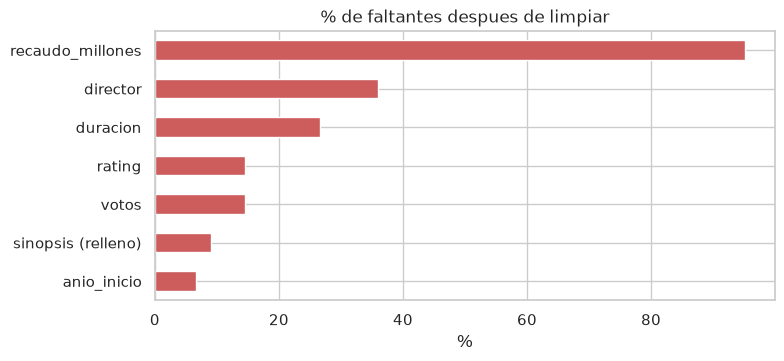

,% faltantes
anio_inicio,6.6
sinopsis (relleno),9.1
votos,14.6
rating,14.6
duracion,26.7
director,36.0
recaudo_millones,95.2


In [7]:
# Porcentaje de faltantes despues de limpiar en las columnas que interesan
faltantes = df[["rating", "votos", "duracion", "anio_inicio", "recaudo_millones"]].isna().mean() * 100
faltantes["sinopsis (relleno)"] = df["sin_sinopsis"].mean() * 100
faltantes["director"] = (df["tiene_director"] == 0).mean() * 100
faltantes = faltantes.round(1).sort_values()
faltantes.plot(kind="barh", color="indianred", figsize=(8, 3.5), title="% de faltantes despues de limpiar")
plt.xlabel("%")
plt.show()
faltantes.to_frame("% faltantes")

Con esos porcentajes se tomaron estas decisiones:

1. **Recaudo:** le falta cerca del 95 % de los datos. Imputar tanto sería inventar la columna, así que no se usa.
2. **Rating:** es la variable objetivo, así que las filas sin rating no sirven para entrenar y se eliminan. Casi todas son títulos que todavía no se estrenan, porque tampoco tienen votos.
3. **Duración y año:** se imputan más adelante con la mediana del conjunto de entrenamiento. La duración se imputa con la mediana de su mismo tipo, porque un episodio dura mucho menos que una película. Se hace después de separar entrenamiento y prueba para que ningún dato de prueba influya en el entrenamiento.
4. **Sinopsis y reparto faltantes:** no se eliminan, porque que falten también es información (suele pasar con títulos pequeños). Se dejan con banderas como `sin_sinopsis` y `tiene_director`.

In [8]:
# Solo los titulos con rating sirven para entrenar
d = df.dropna(subset=["rating"]).reset_index(drop=True)
d["log_votos"] = np.log1p(d["votos"])
print("Titulos con rating:", len(d), "de", len(df))

Titulos con rating: 8167 de 9567


## 3. Análisis exploratorio (EDA)

El análisis exploratorio se hizo sobre los 8167 títulos que tienen rating, siguiendo las herramientas vistas en clase: medidas de tendencia central, de dispersión y de posición, y después gráficos.

**Concepto: estadística descriptiva.** Sirve para resumir los datos antes de modelar y para detectar problemas. Las medidas de **tendencia central** (media, mediana, moda) dicen cuál es el valor típico. Las de **dispersión** (rango, varianza, desviación estándar) dicen qué tan separados están los datos. La media es sensible a los valores extremos y la mediana no, por eso conviene compararlas: si son muy distintas, la variable es asimétrica.

In [9]:
def medidas(serie):
    # Tendencia central y dispersion de una columna numerica
    s = serie.dropna()
    return pd.Series({
        "media": s.mean(), "mediana": s.median(), "moda": s.mode().iloc[0],
        "minimo": s.min(), "maximo": s.max(), "rango": s.max() - s.min(),
        "varianza": s.var(), "desviacion": s.std(), "coef_variacion": s.std() / s.mean(),
    })


numericas = ["rating", "duracion", "votos", "log_votos", "anio_inicio", "n_generos", "n_actores", "largo_sinopsis"]
# Se formatea con separador de miles para que la varianza de los votos no salga en notacion cientifica
d[numericas].apply(medidas).T.map(lambda v: f"{v:,.2f}")

,media,mediana,moda,minimo,maximo,rango,varianza,desviacion,coef_variacion
rating,6.92,7.10,7.20,1.10,9.90,8.80,1.49,1.22,0.18
duracion,69.46,60.00,24.00,1.00,853.00,852.00,"2,254.64",47.48,0.68
votos,"15,146.27",793.00,7.00,5.00,"1,713,028.00","1,713,023.00","4,914,519,563.70","70,103.63",4.63
log_votos,6.82,6.68,2.08,1.79,14.35,12.56,5.37,2.32,0.34
anio_inicio,"2,015.83","2,018.00","2,020.00","1,932.00","2,021.00",89.00,57.31,7.57,0.00
n_generos,2.26,3.00,3.00,1.00,3.00,2.00,0.71,0.84,0.37
n_actores,3.68,4.00,4.00,0.00,4.00,4.00,0.88,0.94,0.25
largo_sinopsis,24.70,25.00,24.00,0.00,70.00,70.00,83.86,9.16,0.37


La media del rating (6.92) es menor que la mediana (7.10) porque una cola de títulos con notas muy bajas arrastra el promedio hacia abajo. En los votos la diferencia es enorme: la media es 15146 y la mediana apenas 793, y la varianza pasa de cuatro mil millones. Unos pocos títulos muy famosos tienen cientos de miles de votos mientras la mayoría no llega a mil, y por eso su coeficiente de variación (desviación dividida entre la media) es 4.63, el más alto de la tabla.

En la duración la moda es 24 minutos, el largo típico de un episodio de comedia o animación, mientras la media es 69 minutos, porque en la misma columna se mezclan episodios y películas. `n_generos` y `n_actores` tienen como máximo 3 y 4 porque IMDb solo muestra esa cantidad en el listado.

**Concepto: percentiles.** El percentil k es el valor por debajo del cual queda el k % de los datos. Los cuartiles son los percentiles 25, 50 y 75. Mirar los percentiles extremos (1 y 99) ayuda a ver hasta dónde llegan las colas sin que un solo valor raro distorsione la lectura.

In [10]:
# Percentiles de las variables numericas
d[numericas].quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).T.round(1)

,0.01,0.10,0.25,0.50,0.75,0.90,0.99
rating,3.4,5.3,6.2,7.1,7.8,8.3,9.2
duracion,11.0,24.0,37.0,60.0,95.0,113.0,236.4
votos,8.0,49.0,167.0,793.0,3782.5,22211.8,297280.9
log_votos,2.2,3.9,5.1,6.7,8.2,10.0,12.6
anio_inicio,1979.7,2010.0,2015.0,2018.0,2020.0,2020.0,2021.0
n_generos,1.0,1.0,1.0,3.0,3.0,3.0,3.0
n_actores,0.0,3.0,4.0,4.0,4.0,4.0,4.0
largo_sinopsis,0.0,14.0,20.0,25.0,31.0,36.0,43.0


El 90 % de los títulos tiene un rating de 8.3 o menos y solo el 1 % pasa de 9.2. En los votos el percentil 50 es 793 y el percentil 99 es cercano a 300 mil, lo que confirma una cola muy larga. La duración tiene su percentil 99 en 236 minutos; por encima de ese valor solo quedan miniseries registradas con la suma de todos sus episodios. El año de inicio muestra que el dataset es muy reciente: la mitad de los títulos empezó en 2018 o después y solo el 10 % es anterior a 2010.

**Concepto: rango intercuartílico (IQR) y outliers.** El IQR es $Q3 - Q1$, el rango del 50 % central de los datos. Un valor se considera atípico si queda por debajo de $Q1 - 1.5 \cdot IQR$ o por encima de $Q3 + 1.5 \cdot IQR$. El **IQR ratio** (IQR dividido por el rango) resume la dispersión. Según lo visto en clase, menos de 0.05 indica una columna casi plana, entre 0.25 y 0.60 una dispersión sana, y más de 0.9 una dispersión tan grande que conviene transformar la variable.

In [11]:
def resumen_iqr(serie):
    # Cuartiles, limites de outliers, cantidad de outliers e IQR ratio
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    ratio = iqr / (s.max() - s.min())
    if ratio < 0.05:
        lectura = "casi plana"
    elif ratio > 0.9:
        lectura = "dispersion muy alta"
    elif 0.25 <= ratio <= 0.60:
        lectura = "dispersion sana"
    else:
        lectura = "intermedia"
    return pd.Series({"Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
                      "lim_inf": round(lim_inf, 2), "lim_sup": round(lim_sup, 2),
                      "outliers": int(((s < lim_inf) | (s > lim_sup)).sum()),
                      "% outliers": round(((s < lim_inf) | (s > lim_sup)).mean() * 100, 1),
                      "IQR_ratio": round(ratio, 3), "lectura": lectura})


d[numericas].apply(resumen_iqr).T

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,% outliers,IQR_ratio,lectura
rating,6.2,7.8,1.6,3.8,10.2,165,2.0,0.182,intermedia
duracion,37.0,95.0,58.0,-50.0,182.0,105,1.5,0.068,intermedia
votos,167.0,3782.5,3615.5,-5256.25,9205.75,1298,15.9,0.002,casi plana
log_votos,5.12,8.24,3.11,0.45,12.91,42,0.5,0.248,intermedia
anio_inicio,2015.0,2020.0,5.0,2007.5,2027.5,681,8.3,0.056,intermedia
n_generos,1.0,3.0,2.0,-2.0,6.0,0,0.0,1.0,dispersion muy alta
n_actores,4.0,4.0,0.0,4.0,4.0,951,11.6,0.0,casi plana
largo_sinopsis,20.0,31.0,11.0,3.5,47.5,383,4.7,0.157,intermedia


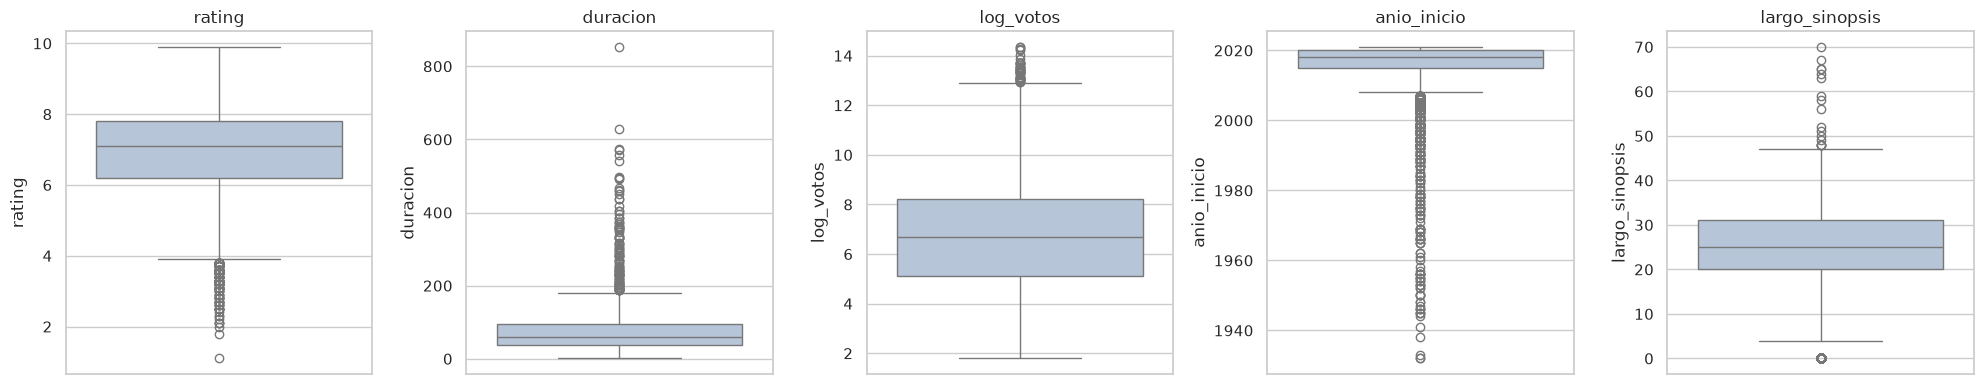

In [12]:
# Diagramas de caja para ver los outliers de forma grafica
fig, ejes = plt.subplots(1, 5, figsize=(20, 4))
for eje, col in zip(ejes, ["rating", "duracion", "log_votos", "anio_inicio", "largo_sinopsis"]):
    sns.boxplot(y=d[col], ax=eje, color="lightsteelblue")
    eje.set_title(col)
plt.tight_layout()
plt.show()

`votos` tiene un IQR ratio de 0.002 y cerca del 16 % de outliers, así que es la columna con la dispersión más problemática. Siguiendo la recomendación de clase para variables muy asimétricas, se le aplicó logaritmo, y `log_votos` queda con un IQR ratio de 0.248 y solo 42 outliers.

`n_actores` sale como casi plana (IQR de 0) porque la gran mayoría de títulos muestra exactamente 4 actores. Aun así se conservó, porque que falten actores sí dice algo: suele pasar en especiales, documentales y títulos pequeños. `n_generos` sale con dispersión muy alta, pero es un falso positivo de la regla: la columna solo puede valer 1, 2 o 3, así que el IQR cubre todo el rango.

Los outliers de `duracion` y del rating son reales (miniseries muy largas, cortos de pocos minutos y títulos muy mal calificados) y no errores de digitación, así que se conservaron. Según lo visto en clase, un dato atípico real se deja y solo se elimina cuando es un error.

**Concepto: histograma.** Muestra cuántos valores caen en cada intervalo de una variable numérica. Sirve para ver la forma de la distribución: si es simétrica, si tiene una cola larga o si tiene varios picos.

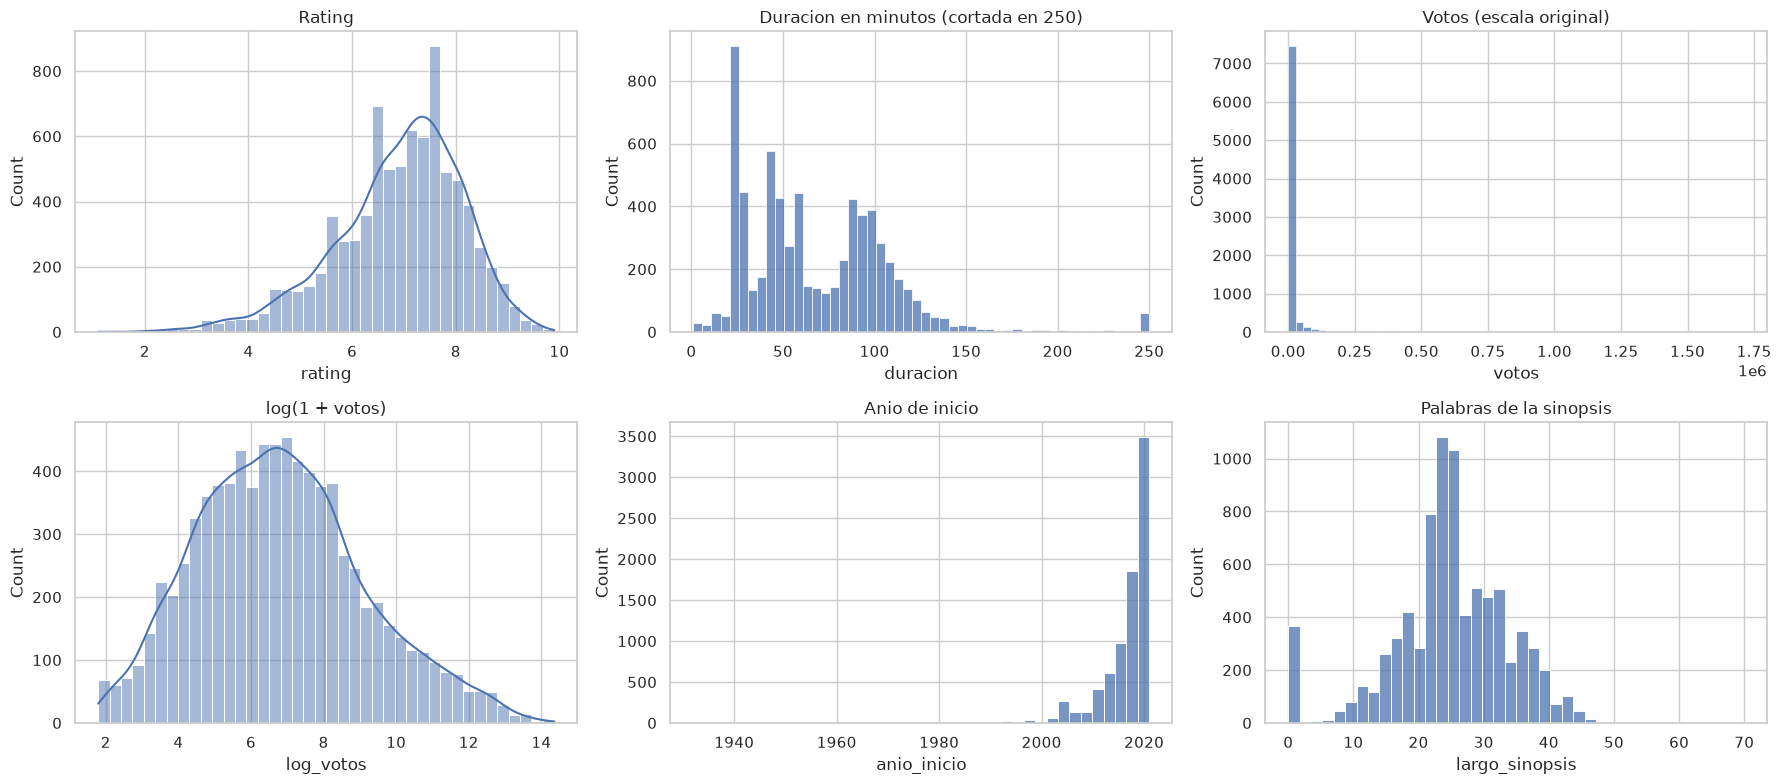

In [13]:
# Histogramas: distribucion de frecuencias de las variables numericas
fig, ejes = plt.subplots(2, 3, figsize=(18, 8))
sns.histplot(d["rating"], bins=40, kde=True, ax=ejes[0, 0]).set_title("Rating")
sns.histplot(d["duracion"].clip(upper=250), bins=50, ax=ejes[0, 1]).set_title("Duracion en minutos (cortada en 250)")
sns.histplot(d["votos"], bins=60, ax=ejes[0, 2]).set_title("Votos (escala original)")
sns.histplot(d["log_votos"], bins=40, kde=True, ax=ejes[1, 0]).set_title("log(1 + votos)")
sns.histplot(d["anio_inicio"].dropna(), bins=40, ax=ejes[1, 1]).set_title("Anio de inicio")
sns.histplot(d["largo_sinopsis"], bins=40, ax=ejes[1, 2]).set_title("Palabras de la sinopsis")
plt.tight_layout()
plt.show()

El rating tiene una distribución sesgada hacia la izquierda: la mayor parte está entre 6 y 8 y hay una cola hacia las notas bajas. La duración muestra dos picos, uno cerca de 20 a 25 minutos (episodios) y otro cerca de 90 a 100 minutos (películas). Los votos en su escala original son casi una sola barra pegada al cero, y después del logaritmo toman una forma parecida a una campana, mucho más fácil de usar en un modelo. El año de inicio se concentra en los últimos cinco años y la sinopsis suele tener entre 20 y 30 palabras, con un grupo en cero que corresponde a los títulos sin sinopsis.

**Concepto: gráfico de barras y gráfico circular.** El de barras compara la cantidad de cada categoría. El circular muestra qué proporción del total representa cada una, y solo se recomienda con pocas categorías (seis o siete como máximo), por eso los tipos muy pequeños se agruparon en *Otros*.

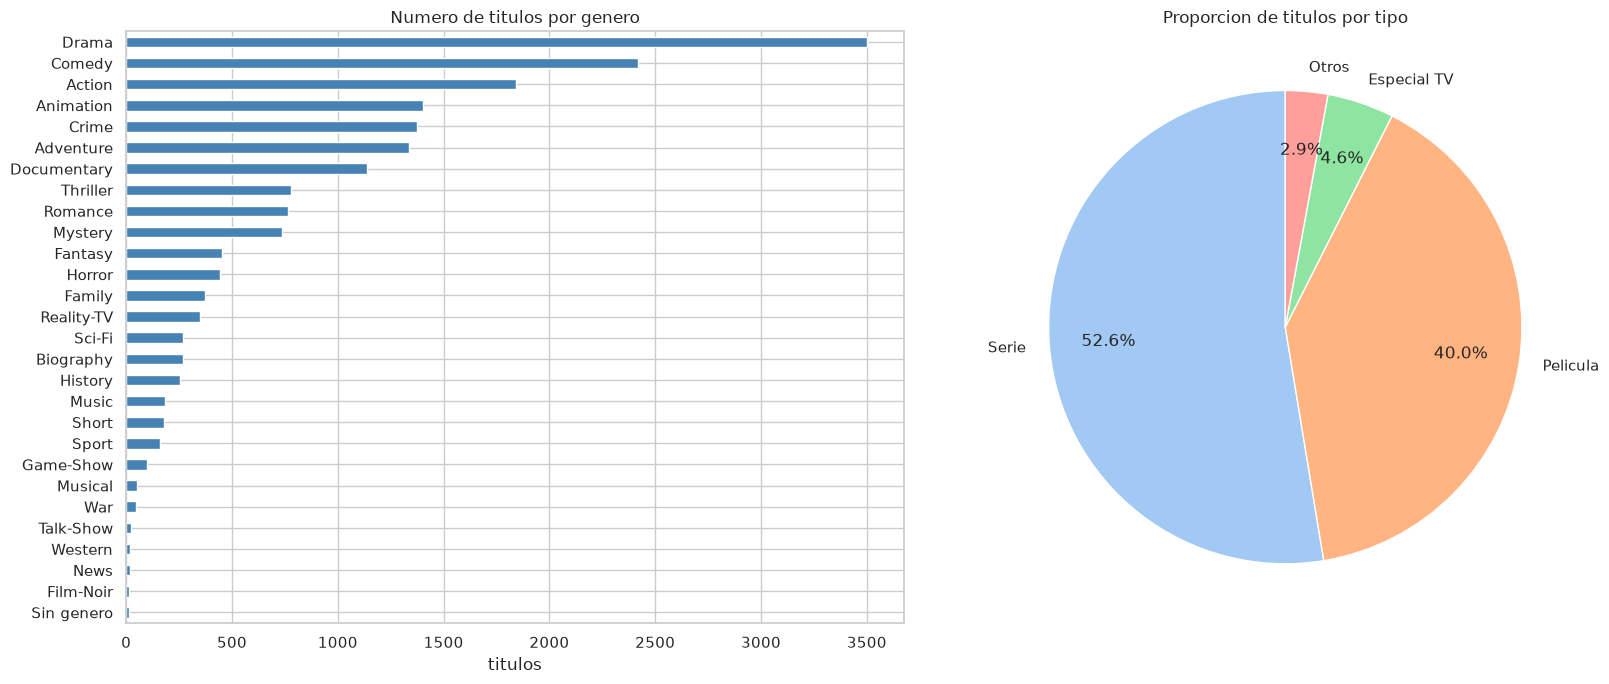

tipo
Serie          4296
Pelicula       3263
Especial TV     372
Pelicula TV     146
Video            83
Corto TV          7
Name: count, dtype: int64


In [14]:
# Grafico de barras de generos y grafico circular de tipos de produccion
conteo_generos = d["genero"].str.get_dummies(sep=", ").sum().sort_values()
conteo_tipos = d["tipo"].value_counts()

fig, ejes = plt.subplots(1, 2, figsize=(17, 7))
conteo_generos.plot(kind="barh", ax=ejes[0], color="steelblue")
ejes[0].set_title("Numero de titulos por genero")
ejes[0].set_xlabel("titulos")

# El circular agrupa los tipos pequenos (menos del 3 %) para que se pueda leer
grandes = conteo_tipos[conteo_tipos / conteo_tipos.sum() >= 0.03]
torta = pd.concat([grandes, pd.Series({"Otros": conteo_tipos.drop(grandes.index).sum()})])
ejes[1].pie(torta, labels=torta.index, autopct="%1.1f%%", startangle=90, pctdistance=0.75,
            colors=sns.color_palette("pastel"), wedgeprops={"edgecolor": "white"})
ejes[1].set_title("Proporcion de titulos por tipo")
plt.tight_layout()
plt.show()
print(conteo_tipos)

Drama es el género más frecuente (3499 títulos), seguido de comedia (2419) y acción (1842). Hay géneros con muy pocos títulos, como cine negro, western o noticias, que difícilmente le sirvan a un modelo.

En el gráfico circular se ve que el 52.6 % de los títulos con rating son series o episodios y el 40.0 % son películas. El dataset no es solo de películas, y como series y películas se comportan distinto en casi todas las variables, esta diferencia tiene que quedar representada en los modelos.

**Concepto: gráfico de dispersión.** Pone un punto por cada título con una variable en cada eje. Sirve para ver si dos variables numéricas se relacionan y de qué forma. El coeficiente de correlación de Pearson ($r$) mide qué tan fuerte es la relación **lineal**: vale 1 o $-1$ si los puntos forman una recta perfecta y 0 si no hay relación lineal.

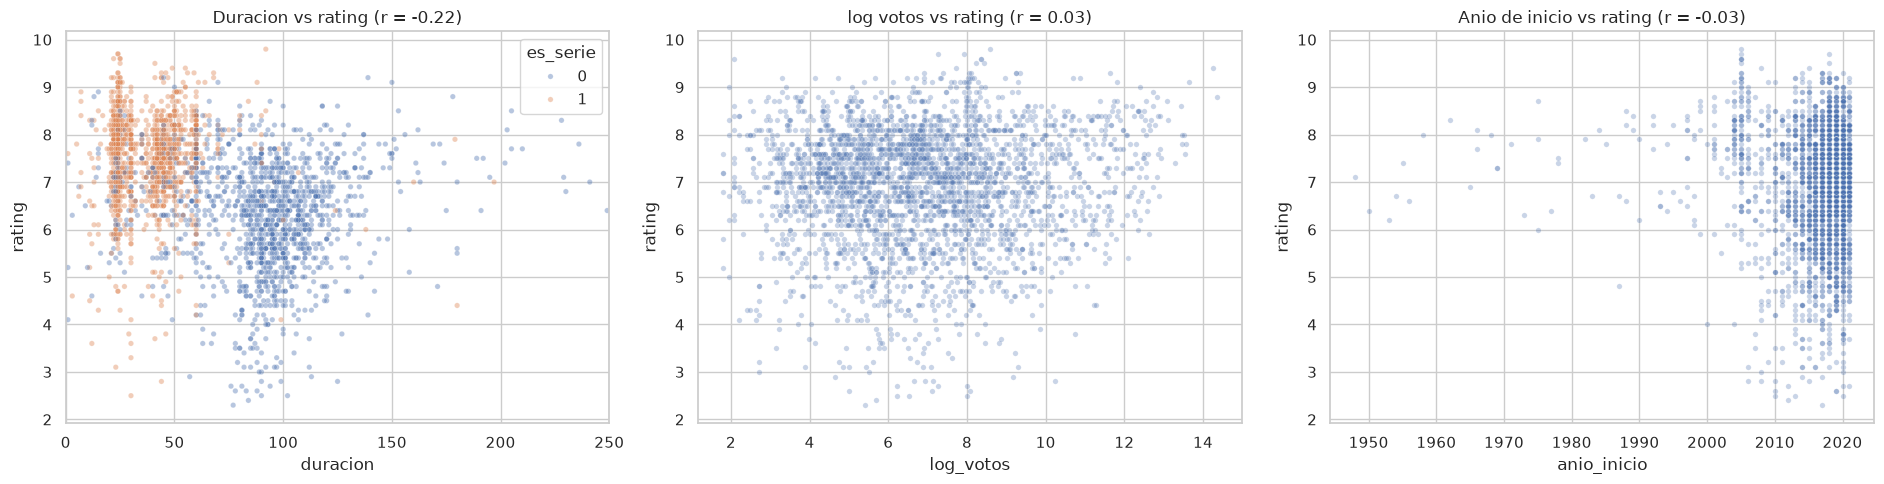

In [15]:
# Graficos de dispersion: relacion entre dos variables numericas
fig, ejes = plt.subplots(1, 3, figsize=(19, 5))
muestra = d.sample(3000, random_state=SEMILLA)  # muestra para que los puntos no se tapen
sns.scatterplot(data=muestra, x="duracion", y="rating", hue="es_serie", alpha=0.4, s=15, ax=ejes[0])
ejes[0].set_xlim(0, 250)
ejes[0].set_title(f"Duracion vs rating (r = {d['duracion'].corr(d['rating']):.2f})")
sns.scatterplot(data=muestra, x="log_votos", y="rating", alpha=0.3, s=15, ax=ejes[1])
ejes[1].set_title(f"log votos vs rating (r = {d['log_votos'].corr(d['rating']):.2f})")
sns.scatterplot(data=muestra, x="anio_inicio", y="rating", alpha=0.3, s=15, ax=ejes[2])
ejes[2].set_title(f"Anio de inicio vs rating (r = {d['anio_inicio'].corr(d['rating']):.2f})")
plt.tight_layout()
plt.show()

Ninguna de las tres nubes de puntos muestra una relación lineal fuerte. La duración tiene una correlación negativa de 0.22 con el rating: los episodios cortos (las series, en otro color) quedan más arriba que las películas. Los votos y el año tienen una correlación prácticamente nula. En el gráfico de votos sí se nota que los títulos con muy pocos votos tienen ratings mucho más dispersos: cuando votan pocas personas, la nota es poco estable.

**Concepto: mapa de calor.** Muestra una matriz con colores. Aquí se usó para la matriz de correlación: los tonos rojos son correlaciones positivas y los azules negativas. Sirve para ver de un vistazo qué variables se relacionan con el rating y cuáles son redundantes entre sí.

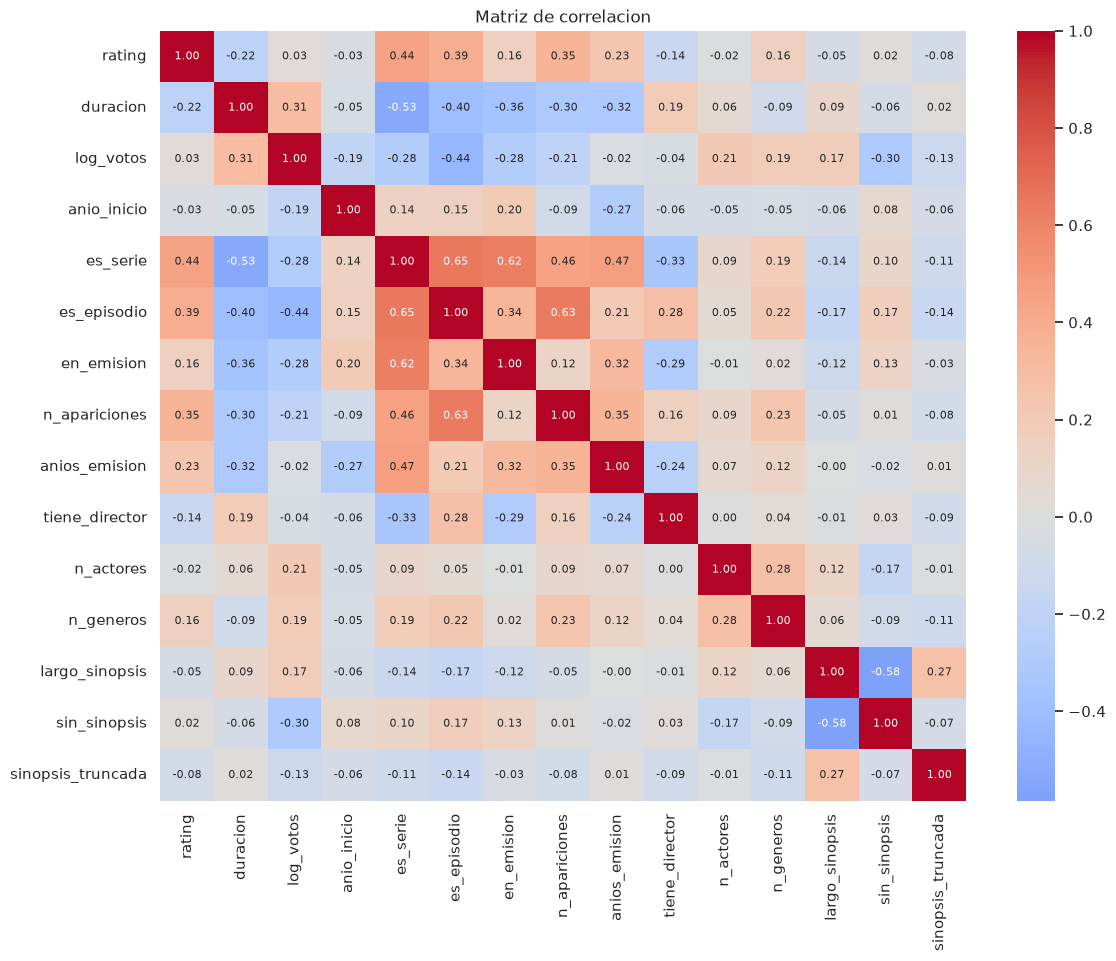

,correlacion con rating
duracion,-0.224
tiene_director,-0.142
sinopsis_truncada,-0.077
largo_sinopsis,-0.052
anio_inicio,-0.029
n_actores,-0.018
sin_sinopsis,0.019
log_votos,0.034
n_generos,0.157
en_emision,0.162


In [16]:
# Mapa de calor con la correlacion de Pearson entre variables numericas
cols_corr = ["rating", "duracion", "log_votos", "anio_inicio", "es_serie", "es_episodio", "en_emision",
             "n_apariciones", "anios_emision", "tiene_director", "n_actores", "n_generos",
             "largo_sinopsis", "sin_sinopsis", "sinopsis_truncada"]
plt.figure(figsize=(13, 10))
sns.heatmap(d[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 8})
plt.title("Matriz de correlacion")
plt.show()
d[cols_corr].corr()["rating"].drop("rating").sort_values().round(3).to_frame("correlacion con rating")

Las variables más relacionadas con el rating son `es_serie` (0.44), `es_episodio` (0.39) y `n_apariciones` (0.36), todas ligadas a si el título es una serie. La duración tiene la correlación negativa más fuerte (0.22), seguida de `tiene_director` (0.14). En el mapa también se ven variables redundantes entre sí: `es_serie`, `es_episodio`, `n_apariciones` y `tiene_director` están bastante correlacionadas, porque las películas y los episodios traen director en el reparto y las series completas no.

Varias variables tienen una correlación casi nula con el rating, como los votos, el año o el largo de la sinopsis. Eso anticipa que un modelo con solo estas columnas va a explicar una parte limitada del rating.

**Concepto: gráfico de radar.** Dibuja varias variables sobre ejes que salen del centro, uno por variable, y une los valores de cada grupo formando un polígono. Sirve para comparar el perfil completo de varios grupos. Como las variables tienen escalas distintas, cada una se normalizó entre 0 y 1.

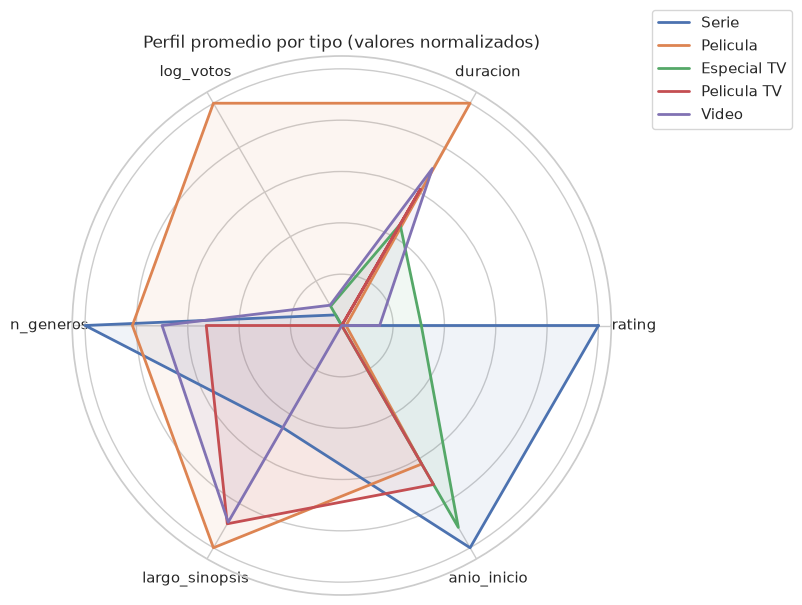

,rating,duracion,log_votos,n_generos,largo_sinopsis,anio_inicio
tipo,,,,,,
Especial TV,6.65,66.84,6.27,1.28,20.90,2016.30
Pelicula,6.31,96.65,7.74,2.20,26.61,2014.59
Pelicula TV,6.29,75.46,6.13,1.88,25.99,2015.14
Serie,7.43,41.98,6.20,2.41,23.52,2016.85
Video,6.46,80.60,6.28,2.07,25.95,2010.84


In [17]:
# Grafico de radar: perfil promedio de cada tipo de produccion
dimensiones = ["rating", "duracion", "log_votos", "n_generos", "largo_sinopsis", "anio_inicio"]
tipos_radar = ["Serie", "Pelicula", "Especial TV", "Pelicula TV", "Video"]
perfil = d[d["tipo"].isin(tipos_radar)].groupby("tipo")[dimensiones].mean()
# Se normaliza cada dimension entre 0 y 1 para poder comparar escalas distintas
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

angulos = np.linspace(0, 2 * np.pi, len(dimensiones), endpoint=False).tolist()
angulos += angulos[:1]
fig = plt.figure(figsize=(7, 7))
eje = plt.subplot(polar=True)
for tipo in tipos_radar:
    valores = perfil_norm.loc[tipo].tolist()
    valores += valores[:1]
    eje.plot(angulos, valores, lw=2, label=tipo)
    eje.fill(angulos, valores, alpha=0.08)
eje.set_xticks(angulos[:-1])
eje.set_xticklabels(dimensiones)
eje.set_yticklabels([])
eje.set_title("Perfil promedio por tipo (valores normalizados)")
eje.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.show()
perfil.round(2)

Los perfiles son muy distintos. Las series tienen el rating promedio más alto (7.43), la menor duración (42 minutos) y el mayor número de géneros. Las películas son las más largas (97 minutos) y las que más votos reciben, pero tienen el rating más bajo junto con las películas de TV (6.31 y 6.29). Los especiales de TV tienen pocos géneros y sinopsis más cortas, y los videos son los títulos más antiguos en promedio. El tipo de producción resume mucha información, por eso se usa como variable en los modelos.

**Concepto: serie de tiempo.** Muestra cómo cambia una variable a lo largo del tiempo, con el tiempo ordenado en el eje horizontal. Aquí se usó el año de inicio de cada título.

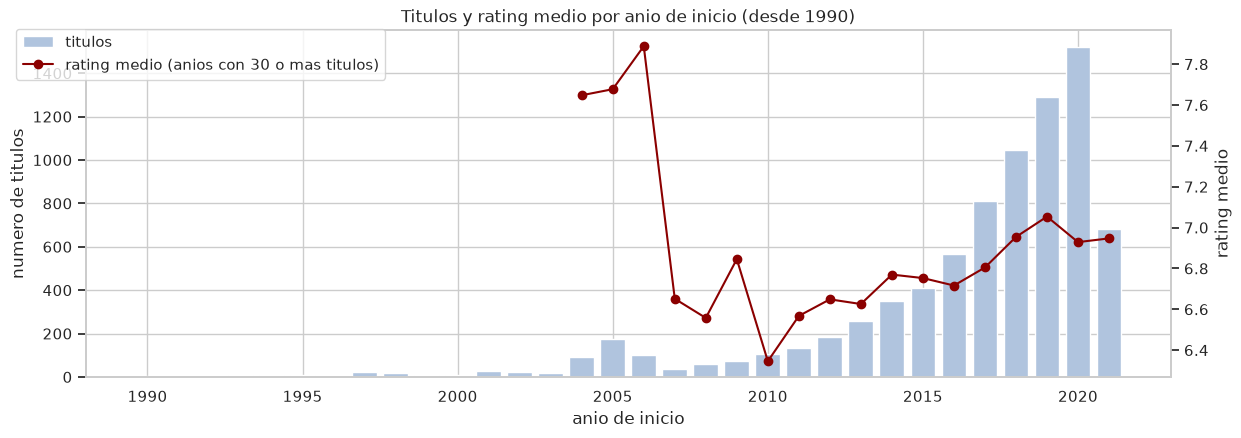

anio_inicio,2004.0,2005.0,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0
titulos,92.00,173.00,99.00,35.00,59.00,75.00,105.00,132.00,183.00,257.00,348.00,411.00,565.00,811.0,1044.00,1291.00,1521.00,684.00
rating_medio,7.65,7.68,7.89,6.65,6.56,6.85,6.35,6.57,6.65,6.63,6.77,6.75,6.72,6.8,6.95,7.05,6.93,6.95


In [18]:
# Serie de tiempo: titulos por anio de inicio y rating promedio de esos titulos
por_anio = (d[d["anio_inicio"] >= 1990].groupby("anio_inicio")
            .agg(titulos=("rating", "size"), rating_medio=("rating", "mean")))
# El promedio solo se dibuja en los anios con al menos 30 titulos, porque con pocos titulos es muy inestable
estable = por_anio[por_anio["titulos"] >= 30]

fig, eje1 = plt.subplots(figsize=(14, 4.5))
eje1.bar(por_anio.index, por_anio["titulos"], color="lightsteelblue", label="titulos")
eje1.set_ylabel("numero de titulos")
eje2 = eje1.twinx()
eje2.plot(estable.index, estable["rating_medio"], color="darkred", marker="o", label="rating medio (anios con 30 o mas titulos)")
eje2.set_ylabel("rating medio")
eje2.grid(False)
eje1.set_xlabel("anio de inicio")
plt.title("Titulos y rating medio por anio de inicio (desde 1990)")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.9))
plt.show()
estable.round(2).T

La cantidad de títulos crece muy rápido desde 2014 y llega a su máximo en 2020 con 1521 títulos. 2021 aparece más bajo, probablemente porque los datos se tomaron durante ese año. El 77 % de los títulos con rating empezó en 2015 o después.

El rating medio solo se dibujó en los años con al menos 30 títulos, porque con menos el promedio salta demasiado. Los títulos que empezaron antes de 2010 tienen un promedio de 7.31, más alto que los de 2010 a 2014 (6.64) y los de 2015 en adelante (6.91). Los picos de 2004 a 2006 se explican porque el 69 % de esos títulos son episodios de series largas y exitosas, como Bleach, Avatar: The Last Airbender o Dexter. Es un sesgo de supervivencia: de los años viejos solo quedan en el listado los títulos que tuvieron éxito, mientras que de los años recientes está casi todo.

### Análisis de las variables objetivo

Para los casos 1 y 2 se usó `buena`, igual que en regresión logística: vale 1 si el rating es mayor o igual a 7.

Para el caso 3 se creó `categoria` con tres clases, con cortes cercanos a los terciles del rating para que queden de tamaño parecido:

1. **Baja:** rating menor a 6.5.
2. **Media:** rating desde 6.5 y menor a 7.5.
3. **Alta:** rating desde 7.5.

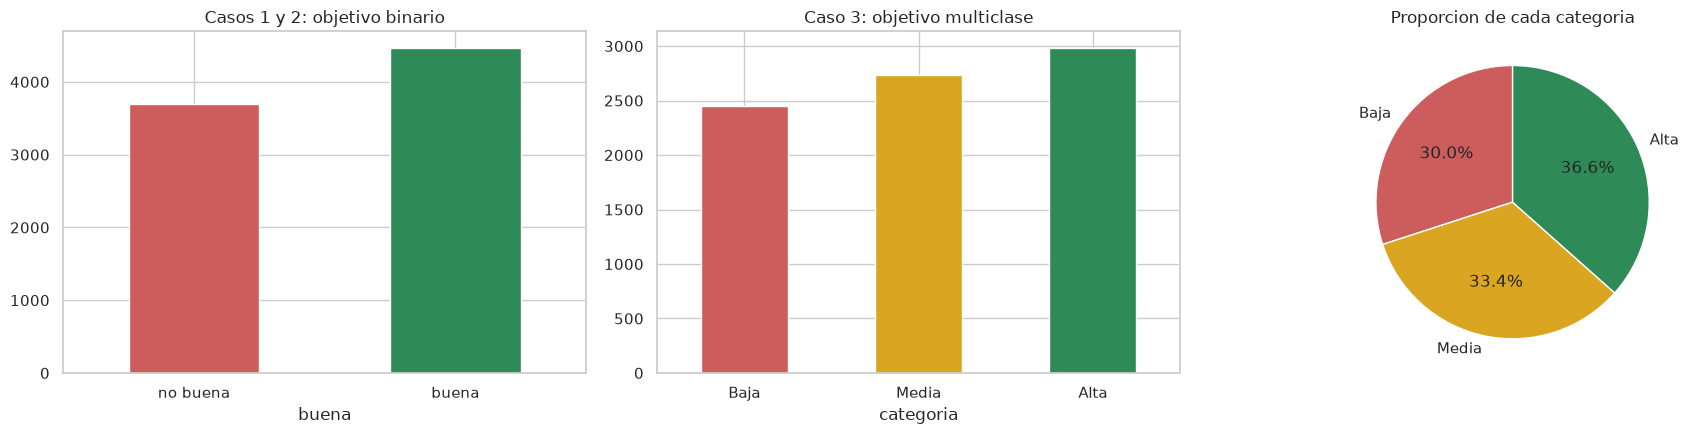

In [19]:
# Objetivo binario (casos 1 y 2) y objetivo multiclase (caso 3)
d["buena"] = (d["rating"] >= 7).astype(int)
d["categoria"] = pd.cut(d["rating"], bins=[0, 6.5, 7.5, 10.01], labels=["Baja", "Media", "Alta"], right=False)

fig, ejes = plt.subplots(1, 3, figsize=(18, 4.5))
d["buena"].value_counts().sort_index().plot(kind="bar", ax=ejes[0], color=["indianred", "seagreen"], rot=0)
ejes[0].set_xticks([0, 1], ["no buena", "buena"])
ejes[0].set_title("Casos 1 y 2: objetivo binario")
conteo_cat = d["categoria"].value_counts().reindex(["Baja", "Media", "Alta"])
conteo_cat.plot(kind="bar", ax=ejes[1], color=["indianred", "goldenrod", "seagreen"], rot=0)
ejes[1].set_title("Caso 3: objetivo multiclase")
ejes[2].pie(conteo_cat, labels=conteo_cat.index, autopct="%1.1f%%", colors=["indianred", "goldenrod", "seagreen"], startangle=90)
ejes[2].set_title("Proporcion de cada categoria")
plt.tight_layout()
plt.show()

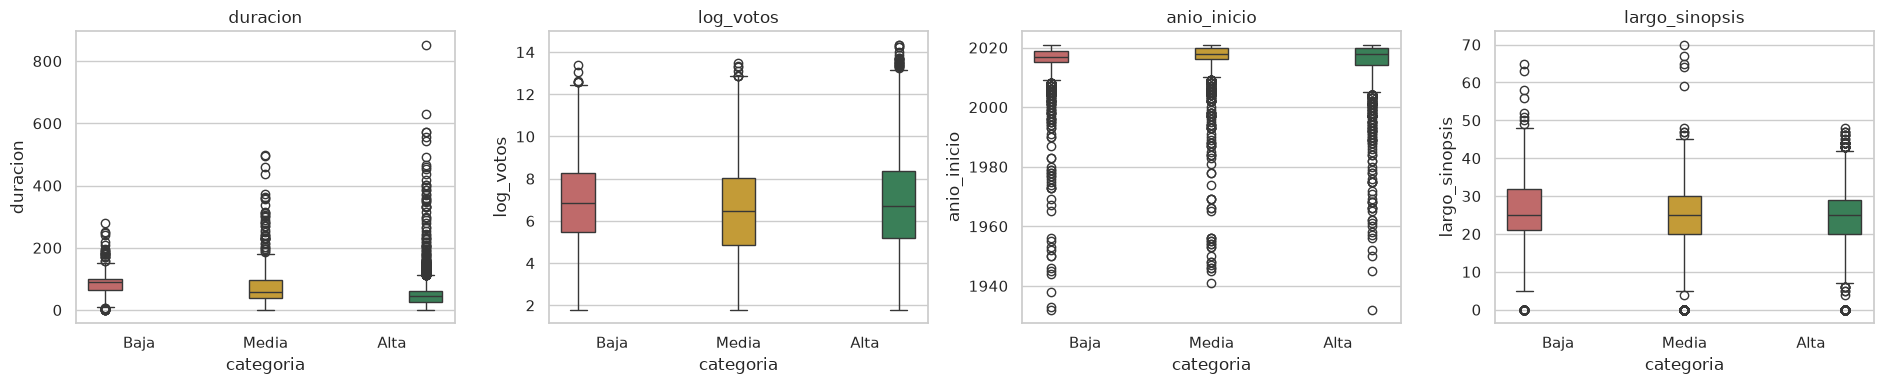

,duracion,log_votos,anio_inicio,largo_sinopsis,n_actores
categoria,,,,,
Baja,90.0,6.869014,2017.0,25.0,4.0
Media,59.0,6.459121,2018.0,25.0,4.0
Alta,45.0,6.723832,2018.0,25.0,4.0


In [20]:
# Variables numericas segun la categoria de rating
fig, ejes = plt.subplots(1, 4, figsize=(19, 4))
for eje, col in zip(ejes, ["duracion", "log_votos", "anio_inicio", "largo_sinopsis"]):
    sns.boxplot(data=d, x="categoria", y=col, ax=eje, hue="categoria",
                palette=["indianred", "goldenrod", "seagreen"], legend=False)
    eje.set_title(col)
plt.tight_layout()
plt.show()
d.groupby("categoria", observed=True)[["duracion", "log_votos", "anio_inicio", "largo_sinopsis", "n_actores"]].median()

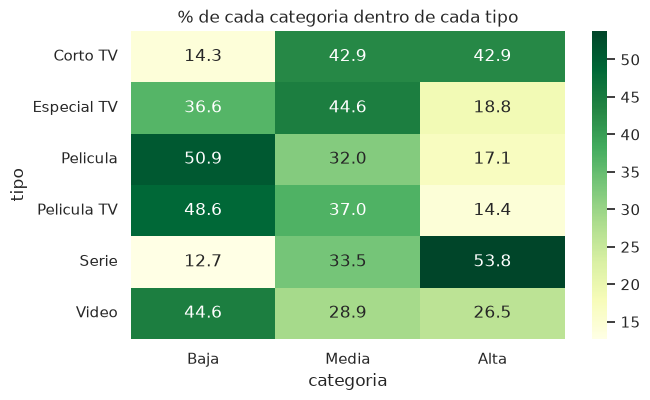

In [21]:
# Composicion de cada tipo de titulo segun la categoria de rating (porcentaje por fila)
tabla_tipo = pd.crosstab(d["tipo"], d["categoria"], normalize="index").mul(100).round(1)
plt.figure(figsize=(7, 4))
sns.heatmap(tabla_tipo, annot=True, fmt=".1f", cmap="YlGn")
plt.title("% de cada categoria dentro de cada tipo")
plt.show()

In [22]:
# Proporcion de categorias segun las variables binarias
binarias = ["es_serie", "es_episodio", "en_emision", "tiene_director", "sin_sinopsis", "sinopsis_truncada"]
filas = {}
for c in binarias:
    for v in (0, 1):
        filas[f"{c} = {v}"] = d.loc[d[c] == v, "categoria"].value_counts(normalize=True).mul(100)
pd.DataFrame(filas).T[["Baja", "Media", "Alta"]].round(1)

categoria,Baja,Media,Alta
es_serie = 0,49.2,33.4,17.4
es_serie = 1,12.7,33.5,53.8
es_episodio = 0,40.7,33.8,25.5
es_episodio = 1,7.2,32.7,60.1
en_emision = 0,35.3,31.9,32.8
en_emision = 1,17.6,37.1,45.3
tiene_director = 0,19.4,36.6,44.0
tiene_director = 1,35.1,31.9,33.0
sin_sinopsis = 0,30.4,32.9,36.7
sin_sinopsis = 1,21.6,44.5,33.9


Las tres clases de rating quedaron balanceadas: 30.0 % baja, 33.4 % media y 36.6 % alta. Un modelo que diga siempre "Alta" acertaría el 36.6 %, así que ese es el mínimo a superar en el caso 3.

La duración baja a medida que sube la categoría: la mediana es 90 minutos en baja, 59 en media y 45 en alta. Los votos no siguen un orden: la clase media es la que tiene menos votos, y la baja y la alta tienen más. Esa relación en forma de U no la puede aprender un modelo lineal, pero un árbol sí. El largo de la sinopsis y el número de actores tienen exactamente la misma mediana en las tres clases.

El tipo de título cambia mucho la distribución: el 53.8 % de las series está en categoría alta y solo el 12.7 % en baja, mientras que en las películas el 50.9 % está en baja y solo el 17.1 % en alta. Entre los episodios el 60.1 % es de categoría alta. Tener director registrado aumenta la proporción de títulos de categoría baja (35.1 % contra 19.4 %).

### Resumen del análisis exploratorio

1. Las clases del objetivo binario (55 % y 45 %) y del multiclase (30 %, 33 % y 37 %) están balanceadas.
2. La estructura del título (serie, episodio, tipo) es lo que más cambia el rating.
3. Varias relaciones no son lineales, como la de los votos con la categoría o la de la duración con el rating. Ahí un modelo basado en árboles tiene ventaja.
4. Los outliers son reales y se conservaron. Para Random Forest no hace falta escalar ni transformar, porque los árboles solo comparan contra umbrales, pero se usan las mismas variables de los otros notebooks para comparar en igualdad de condiciones.

## 4. Preparación de los datos para los modelos

### División entrenamiento y prueba

**Concepto.** Los datos se dividen en entrenamiento y prueba para medir el modelo con títulos que nunca vio. Si se evaluara con los mismos datos del entrenamiento, las métricas saldrían infladas.

Los episodios de una misma serie se parecen mucho entre sí: comparten título, reparto, duración y género. Con una división aleatoria normal, unos episodios quedarían en entrenamiento y otros en prueba, y el modelo reconocería la serie en vez de aprender algo general. Por eso se usó `GroupShuffleSplit` agrupando por título: todos los episodios de una serie quedan del mismo lado. Se dejó el 80 % para entrenar y el 20 % para probar.

In [23]:
# Division 80/20 agrupando por titulo
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(d, groups=d["titulo"]))
train, test = d.iloc[idx_train].copy(), d.iloc[idx_test].copy()
print("Entrenamiento:", len(train), "filas | Prueba:", len(test), "filas")
print("Titulos compartidos entre ambos:", len(set(train["titulo"]) & set(test["titulo"])))

Entrenamiento: 6526 filas | Prueba: 1641 filas
Titulos compartidos entre ambos: 0


### Imputación y variables derivadas

La duración y el año faltantes se llenaron con medianas calculadas **solo con el entrenamiento** y aplicadas igual a prueba. Así ninguna información de prueba se filtra al modelo. También se crearon estas variables:

1. `log_votos_anio`: los votos divididos entre los años que lleva el título publicado, en logaritmo. Un título de 2021 con 5000 votos es más popular que uno de 2005 con los mismos votos.
2. `log_apariciones`: logaritmo de cuántas filas tiene el título. Una serie con muchos episodios listados suele ser una serie con muchos seguidores.
3. **Géneros y tipo en one hot:** una columna 0/1 por cada categoría. Un título puede tener varios géneros a la vez. Del tipo se deja por fuera `Pelicula`, que queda como categoría base, y `Serie`, que ya está en `es_serie`. Si se dejaran todas, una columna sería combinación exacta de las otras, y eso daña la regresión lineal.
4. **Rangos de duración:** la duración se dividió en intervalos (0 a 15 minutos, 15 a 30, etc.) y cada intervalo quedó como columna 0/1. Esto se llama **discretización** y sirve para que un modelo lineal pueda representar relaciones que no son una recta. En el análisis exploratorio se vio que el rating sube en los episodios de 20 a 60 minutos, baja en las películas de 90 minutos y vuelve a subir en las miniseries largas.

In [24]:
CORTES_DURACION = [0, 15, 30, 50, 70, 85, 100, 130, 180, np.inf]
ETQ_DURACION = ["0_15", "15_30", "30_50", "50_70", "70_85", "85_100", "100_130", "130_180", "180_mas"]


def imputar_y_derivar(train, test):
    # Las medianas salen solo del entrenamiento
    mediana_tipo = train.groupby("tipo")["duracion"].median()
    mediana_duracion = train["duracion"].median()
    mediana_anio = train["anio_inicio"].median()
    partes = []
    for parte in (train, test):
        p = parte.copy()
        p["duracion_faltante"] = p["duracion"].isna().astype(int)
        p["duracion"] = p["duracion"].fillna(p["tipo"].map(mediana_tipo)).fillna(mediana_duracion)
        p["anio_inicio"] = p["anio_inicio"].fillna(mediana_anio)
        p["log_votos_anio"] = np.log1p(p["votos"] / (2022 - p["anio_inicio"]).clip(lower=1))
        p["log_apariciones"] = np.log(p["n_apariciones"])
        # Rangos de duracion en one hot
        rangos = pd.cut(p["duracion"], bins=CORTES_DURACION, labels=ETQ_DURACION)
        p = pd.concat([p, pd.get_dummies(rangos, prefix="dur", dtype=int)], axis=1)
        partes.append(p)
    return partes


def one_hot(train, test):
    # Generos y tipo en columnas 0/1 con las mismas columnas en ambos conjuntos
    generos = sorted(set(g for lista in train["genero"].str.split(", ") for g in lista))
    tipos = [t for t in sorted(train["tipo"].unique()) if t not in ("Pelicula", "Serie")]
    cols_gen = ["gen_" + g.replace("-", "_").replace(" ", "_") for g in generos]
    cols_tipo = ["tipo_" + t.replace(" ", "_") for t in tipos]
    for p in (train, test):
        lista = p["genero"].str.split(", ")
        for g, c in zip(generos, cols_gen):
            p[c] = lista.apply(lambda x: int(g in x))
        for t, c in zip(tipos, cols_tipo):
            p[c] = (p["tipo"] == t).astype(int)
    return cols_gen, cols_tipo


train, test = imputar_y_derivar(train, test)
cols_generos, cols_tipos = one_hot(train, test)
cols_duracion = ["dur_" + e for e in ETQ_DURACION]
print("Generos:", len(cols_generos), "| tipos:", cols_tipos)

Generos: 28 | tipos: ['tipo_Corto_TV', 'tipo_Especial_TV', 'tipo_Pelicula_TV', 'tipo_Video']


### Historial del director, de los actores y puntaje de la sinopsis

El análisis exploratorio mostró que las variables del archivo explican solo una parte del rating. Lo que más pesa en la calificación de una película, como quién la dirige, quién actúa y de qué trata, viene como texto. Para aprovecharlo se crearon tres tipos de variables nuevas.

**Concepto: codificación por objetivo (target encoding).** Cada director o actor se reemplaza por el rating promedio de los otros títulos en los que participó. Sirve para convertir miles de nombres distintos en un solo número con significado. Por ejemplo, un director cuyas otras obras tienen un promedio de 8 probablemente haga títulos bien calificados. Se aplicaron dos cuidados:

1. **Suavizado:** si una persona tiene muy pocos títulos, su promedio no es confiable. Por eso se mezcla con el promedio general usando $\frac{\text{suma} + k \cdot \text{media global}}{n + k}$ con $k = 5$. Con pocos títulos el valor queda cerca del promedio general, y con muchos títulos pesa el promedio propio.
2. **Cálculo fuera de pliegue (out of fold):** si el rating de un título se usara para calcular su propia variable, el modelo estaría viendo la respuesta. Por eso el entrenamiento se dividió en 5 partes agrupadas por título y el valor de cada parte se calculó solo con las otras cuatro. Para el conjunto de prueba se usó todo el entrenamiento.

Además se guardó cuántos títulos previos tiene cada persona (`log_exp_director` y `log_exp_actores`), porque la experiencia también puede influir.

**Concepto: TF IDF.** Convierte un texto en números: cada palabra (o pareja de palabras) recibe un peso que es alto si aparece mucho en ese texto pero poco en el resto. Se aplicó a la sinopsis junto con el género, y sobre esa representación se entrenó una regresión Ridge (regresión lineal con regularización) que predice el rating. Esa predicción quedó como una sola columna, `puntaje_texto`, calculada también fuera de pliegue. Así los modelos del taller reciben la información del texto sin tener que manejar miles de columnas.

In [25]:
def codificar_personas(ajuste, aplicar, columna, media, k=5):
    # Promedio suavizado del rating de cada persona, usando solo las filas de "ajuste"
    filas = ajuste[[columna, "titulo", "rating"]].explode(columna).dropna(subset=[columna])
    filas = filas.groupby([columna, "titulo"])["rating"].mean().reset_index()  # un voto por titulo
    estad = filas.groupby(columna)["rating"].agg(["sum", "count"])
    suavizado = (estad["sum"] + k * media) / (estad["count"] + k)

    def valor(lista):
        conocidos = [p for p in lista if p in suavizado.index]
        promedio = np.mean([suavizado[p] for p in conocidos]) if conocidos else media
        return promedio, estad.loc[conocidos, "count"].sum() if conocidos else 0

    resultado = aplicar[columna].apply(valor)
    return resultado.str[0].to_numpy(), resultado.str[1].to_numpy()


def texto_de(df):
    return (df["sinopsis"] + " " + df["genero"]).to_numpy()


def modelo_texto(ajuste):
    # TF IDF de la sinopsis y el genero, y una regresion Ridge que predice el rating
    tfidf = TfidfVectorizer(min_df=3, ngram_range=(1, 2), stop_words="english", sublinear_tf=True)
    ridge = Ridge(alpha=3).fit(tfidf.fit_transform(texto_de(ajuste)), ajuste["rating"])
    return lambda df: ridge.predict(tfidf.transform(texto_de(df)))


def agregar_codificaciones(train, test, pliegues=5):
    nuevas = ["te_director", "te_actores", "exp_director", "exp_actores", "puntaje_texto"]
    for c in nuevas:
        train[c] = 0.0
    # Fuera de pliegue: cada parte del entrenamiento se calcula con las otras cuatro
    for idx_ajuste, idx_aplicar in GroupKFold(pliegues).split(train, groups=train["titulo"]):
        ajuste, aplicar = train.iloc[idx_ajuste], train.iloc[idx_aplicar]
        media = ajuste["rating"].mean()
        for columna, nombre in [("directores", "director"), ("actores", "actores")]:
            valor, conteo = codificar_personas(ajuste, aplicar, columna, media)
            train.iloc[idx_aplicar, train.columns.get_loc("te_" + nombre)] = valor
            train.iloc[idx_aplicar, train.columns.get_loc("exp_" + nombre)] = conteo
        train.iloc[idx_aplicar, train.columns.get_loc("puntaje_texto")] = modelo_texto(ajuste)(aplicar)
    # El conjunto de prueba se calcula con todo el entrenamiento
    media = train["rating"].mean()
    for columna, nombre in [("directores", "director"), ("actores", "actores")]:
        test["te_" + nombre], test["exp_" + nombre] = codificar_personas(train, test, columna, media)
    test["puntaje_texto"] = modelo_texto(train)(test)
    for p in (train, test):
        p["log_exp_director"] = np.log1p(p["exp_director"])
        p["log_exp_actores"] = np.log1p(p["exp_actores"])


agregar_codificaciones(train, test)
print("Titulos de prueba con algun actor conocido:", round((test["exp_actores"] > 0).mean() * 100, 1), "%")
print("Titulos de prueba con director conocido:", round((test["exp_director"] > 0).mean() * 100, 1), "%")
train[["titulo", "rating", "te_director", "te_actores", "puntaje_texto"]].head()

Titulos de prueba con algun actor conocido: 68.5 %
Titulos de prueba con director conocido: 19.9 %


,titulo,rating,te_director,te_actores,puntaje_texto
0,Blood Red Sky,6.1,6.908504,7.023753,4.855131
1,Masters of the Universe: Revelation,5.0,6.895613,6.840653,6.944161
2,The Walking Dead,8.2,6.908504,6.890420,6.036812
3,Rick and Morty,9.2,6.903007,7.001136,6.480148
4,Outer Banks,7.6,6.923386,6.923386,6.463898


In [26]:
# Correlacion de las variables nuevas con el rating, medida en entrenamiento
nuevas = ["te_director", "te_actores", "log_exp_director", "log_exp_actores", "puntaje_texto",
          "log_votos_anio", "log_apariciones"]
train[nuevas + ["rating"]].corr()["rating"].drop("rating").sort_values().round(3).to_frame("correlacion con rating")

,correlacion con rating
log_exp_director,-0.046
log_votos_anio,0.037
log_exp_actores,0.073
te_director,0.190
te_actores,0.233
puntaje_texto,0.350
log_apariciones,0.407


Las variables nuevas sí se relacionan con el rating. `puntaje_texto` llega a una correlación de 0.35, más alta que cualquier variable numérica original salvo las de estructura de serie. `te_actores` (0.23) y `te_director` (0.19) también aportan, aunque solo el 68.5 % de los títulos de prueba tiene algún actor conocido y apenas el 19.9 % tiene un director conocido; en el resto la variable queda en el promedio general. La cantidad de títulos previos del director o de los actores casi no se relaciona con el rating. `log_apariciones` (0.41) confirma que las series con muchos episodios listados tienden a estar mejor calificadas.

In [27]:
# Grupos de variables que se usan en los modelos
vars_estructura = ["es_serie", "es_episodio", "en_emision", "log_apariciones", "anios_emision"]
vars_extra = ["anio_inicio", "log_votos_anio", "tiene_director", "n_directores", "n_actores", "n_generos",
              "largo_sinopsis", "sin_sinopsis", "sinopsis_truncada", "duracion_faltante"]
vars_personas_texto = ["te_director", "te_actores", "log_exp_director", "log_exp_actores", "puntaje_texto"]
todas = ["duracion", "log_votos"] + vars_estructura + vars_extra + vars_personas_texto + cols_generos + cols_tipos

# Variables candidatas para los casos con una y dos columnas
candidatas = ["duracion", "log_votos", "es_serie", "es_episodio", "log_apariciones", "anios_emision",
              "tiene_director", "anio_inicio", "log_votos_anio", "te_director", "te_actores", "puntaje_texto"]
cv = GroupKFold(n_splits=5)
print("Columnas caracteristica disponibles:", len(todas))

Columnas caracteristica disponibles: 54


## 5. Métricas y control del sobreajuste

Se usaron las mismas métricas de la regresión logística: matriz de confusión, accuracy, precision, recall, F1 y AUC. En el caso multiclase, precision, recall y F1 se calculan por clase y se promedian con **macro average**, es decir, cada clase pesa igual sin importar cuántas filas tenga.

**Concepto: sobreajuste (overfitting).** Pasa cuando el modelo aprende detalles y ruido del entrenamiento que no se repiten en datos nuevos. Se nota porque la métrica de entrenamiento queda muy por encima de la de prueba. En Random Forest se controla con dos hiperparámetros:

1. `min_samples_leaf`: mínimo de filas que debe tener cada hoja. Con valores altos las hojas no pueden quedar con uno o dos títulos memorizados.
2. `max_features`: cuántas columnas mira cada división. Menos columnas hacen los árboles más distintos entre sí, y eso mejora la votación.

Los valores se escogieron con **validación cruzada** de 5 partes dentro del entrenamiento, agrupando por título. El conjunto de prueba no se usa para escoger nada.

In [28]:
N_ARBOLES = 300
ETQ_BIN = ["no buena", "buena"]
ETQ_MULTI = ["Baja", "Media", "Alta"]


def crear_rf(min_samples_leaf=1, max_features="sqrt"):
    return RandomForestClassifier(n_estimators=N_ARBOLES, min_samples_leaf=min_samples_leaf, max_features=max_features,
                                  random_state=SEMILLA, n_jobs=-1)


def crear_logistica(C=1.0):
    # Mismo modelo del notebook de regresion logistica, para comparar
    return make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=5000))


def buscar_rf(columnas, objetivo, scoring, grilla):
    # Validacion cruzada agrupada dentro del entrenamiento para escoger los hiperparametros
    busqueda = GridSearchCV(crear_rf(), grilla, cv=cv, scoring=scoring)
    busqueda.fit(train[columnas], train[objetivo], groups=train["titulo"])
    resultados = pd.DataFrame(busqueda.cv_results_["params"])
    resultados["puntaje_validacion"] = busqueda.cv_results_["mean_test_score"]
    print("Mejores hiperparametros:", busqueda.best_params_)
    return busqueda.best_params_, resultados.sort_values("puntaje_validacion", ascending=False)


def evaluar(modelo, columnas, objetivo, nombre, etiquetas, mostrar=True, normalizar=None):
    # Entrena, predice y calcula las metricas en entrenamiento y prueba
    modelo.fit(train[columnas], train[objetivo])
    pred = modelo.predict(test[columnas])
    binario = len(etiquetas) == 2
    promedio = "binary" if binario else "macro"
    metricas = {
        "modelo": nombre,
        "n_variables": len(columnas),
        "accuracy_train": accuracy_score(train[objetivo], modelo.predict(train[columnas])),
        "accuracy": accuracy_score(test[objetivo], pred),
        "precision": precision_score(test[objetivo], pred, average=promedio),
        "recall": recall_score(test[objetivo], pred, average=promedio),
        "f1": f1_score(test[objetivo], pred, average=promedio),
    }
    if binario:
        metricas["auc"] = roc_auc_score(test[objetivo], modelo.predict_proba(test[columnas])[:, 1])
    if mostrar:
        orden = [0, 1] if binario else etiquetas
        fig, eje = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(confusion_matrix(test[objetivo], pred, labels=orden), display_labels=etiquetas).plot(
            ax=eje, cmap="Greens", colorbar=False)
        eje.set_title(nombre)
        plt.show()
        print(classification_report(test[objetivo], pred, labels=orden, target_names=etiquetas, digits=3))
    return modelo, pred, metricas


GRILLA_HOJA = {"min_samples_leaf": [1, 5, 10, 20, 40, 80]}
GRILLA_COMPLETA = {"min_samples_leaf": [1, 3, 5, 10], "max_features": ["sqrt", 0.3]}

### Variables de los casos 1 y 2

El taller pide resolver los mismos casos 1 y 2 de la regresión logística. Para usar exactamente las mismas variables se repitió aquí la selección de ese notebook: la variable y la pareja con mejor AUC en validación cruzada con regresión logística.

In [29]:
def auc_logistica(columnas):
    return cross_val_score(crear_logistica(), train[columnas], train["buena"],
                           groups=train["titulo"], cv=cv, scoring="roc_auc").mean()


var_1 = pd.Series({c: auc_logistica([c]) for c in candidatas}).idxmax()
par = pd.Series({" + ".join(p): auc_logistica(list(p)) for p in combinations(candidatas, 2)}).idxmax().split(" + ")
print("Variable del caso 1:", var_1)
print("Pareja del caso 2:", par)

Variable del caso 1: es_serie
Pareja del caso 2: ['es_serie', 'puntaje_texto']


## 6. Caso 1: Random Forest con una variable

**Enunciado.** Resolver el mismo caso 1 de la regresión logística pero con Random Forest, obtener métricas de desempeño (matriz de confusión, accuracy, f1 score, precision, recall), redactar los procesos relevantes y sacar conclusiones.

Mejores hiperparametros: {'min_samples_leaf': 1}


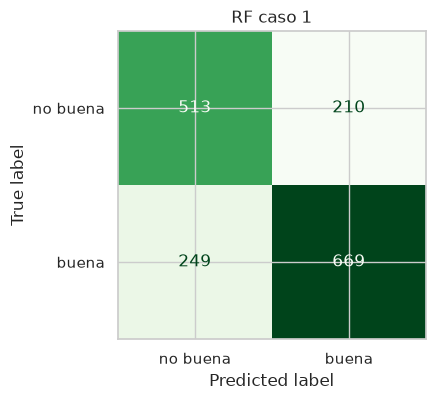

              precision    recall  f1-score   support

    no buena      0.673     0.710     0.691       723
       buena      0.761     0.729     0.745       918

    accuracy                          0.720      1641
   macro avg      0.717     0.719     0.718      1641
weighted avg      0.722     0.720     0.721      1641



,n_variables,accuracy_train,accuracy,precision,recall,f1,auc
modelo,,,,,,,
Logistica caso 1,1,0.6987,0.7203,0.7611,0.7288,0.7446,0.7192
RF caso 1,1,0.6987,0.7203,0.7611,0.7288,0.7446,0.7192


In [30]:
parametros_1, busqueda_1 = buscar_rf([var_1], "buena", "roc_auc", GRILLA_HOJA)
rf_1, pred_1, met_1 = evaluar(crear_rf(**parametros_1), [var_1], "buena", "RF caso 1", ETQ_BIN)
log_1, _, met_1_log = evaluar(crear_logistica(), [var_1], "buena", "Logistica caso 1", ETQ_BIN, mostrar=False)
pd.DataFrame([met_1_log, met_1]).set_index("modelo").round(4)

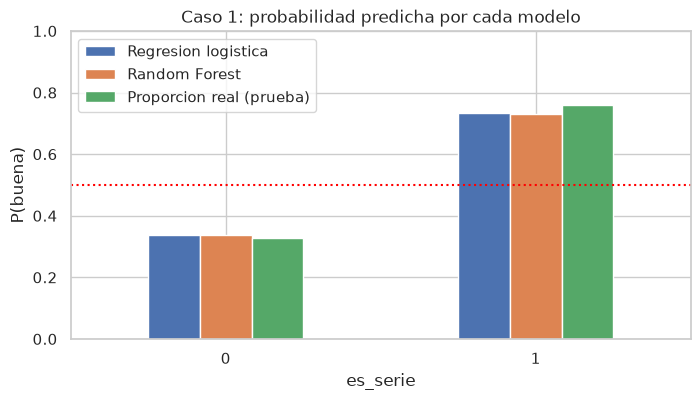

,Regresion logistica,Random Forest,Proporcion real (prueba)
es_serie,,,
0,0.338,0.339,0.327
1,0.732,0.732,0.761


In [31]:
# Probabilidad que asigna cada modelo segun el valor de la variable
valores = sorted(train[var_1].unique()) if train[var_1].nunique() <= 2 else np.linspace(train[var_1].min(), train[var_1].max(), 200)
malla = pd.DataFrame({var_1: valores})
comparacion = pd.DataFrame({
    "Regresion logistica": log_1.predict_proba(malla)[:, 1],
    "Random Forest": rf_1.predict_proba(malla)[:, 1],
}, index=malla[var_1])
if train[var_1].nunique() <= 2:
    comparacion["Proporcion real (prueba)"] = test.groupby(var_1)["buena"].mean().values
    comparacion.plot(kind="bar", rot=0, figsize=(8, 4), ylim=(0, 1))
else:
    comparacion.plot(figsize=(9, 4))
plt.axhline(0.5, color="red", ls=":")
plt.ylabel("P(buena)")
plt.title("Caso 1: probabilidad predicha por cada modelo")
plt.show()
comparacion.round(3)

### Conclusiones del caso 1

El Random Forest da **exactamente las mismas métricas** que la regresión logística: accuracy de 0.720, precision de 0.761, recall de 0.729, F1 de 0.745 y AUC de 0.719. Con una sola variable binaria solo existen dos grupos de títulos (series y no series), y cualquier modelo termina asignándole a cada grupo su proporción de títulos buenos. La tabla lo confirma: la regresión logística da 0.338 y 0.732, el Random Forest da 0.339 y 0.732, y las dos probabilidades quedan del mismo lado del umbral de 0.5.

Por la misma razón el Random Forest no puede sobreajustar aquí: aunque la validación cruzada escogió hojas de tamaño 1, no hay nada que memorizar con dos valores posibles. La ventaja de Random Forest solo aparece cuando hay variables continuas o combinaciones de variables, como en el caso 2.

## 7. Caso 2: Random Forest con varias variables

**Enunciado.** Resolver el mismo caso 2 de la regresión logística pero con Random Forest y obtener las mismas métricas. Después resolverlo con Random Forest aplicado a todas las columnas característica.

Se hizo en dos partes:

1. **Parte A:** la misma pareja del paso A de la regresión logística.
2. **Parte B:** todas las columnas característica, las mismas del modelo final de la regresión logística.

Mejores hiperparametros: {'min_samples_leaf': 80}
 min_samples_leaf  puntaje_validacion
               80              0.7496
               40              0.7435
               20              0.7335
               10              0.7161
                5              0.6971
                1              0.6631


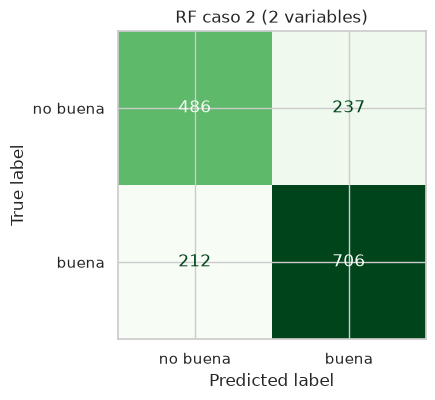

              precision    recall  f1-score   support

    no buena      0.696     0.672     0.684       723
       buena      0.749     0.769     0.759       918

    accuracy                          0.726      1641
   macro avg      0.722     0.721     0.721      1641
weighted avg      0.726     0.726     0.726      1641



In [32]:
# Parte A: la pareja de variables
parametros_2, busqueda_2 = buscar_rf(par, "buena", "roc_auc", GRILLA_HOJA)
print(busqueda_2.round(4).to_string(index=False))
rf_2, pred_2, met_2 = evaluar(crear_rf(**parametros_2), par, "buena", "RF caso 2 (2 variables)", ETQ_BIN)

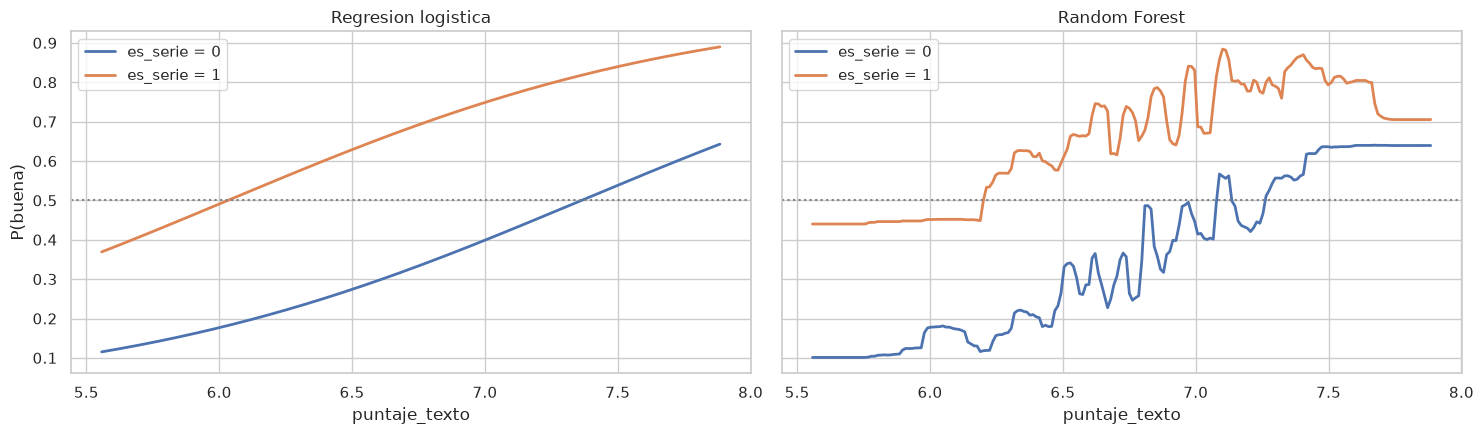

In [33]:
# Probabilidad predicha segun la variable continua de la pareja: logistica vs Random Forest
continua = max(par, key=lambda c: train[c].nunique())
otra = [c for c in par if c != continua][0]
log_2 = crear_logistica().fit(train[par], train["buena"])
x = np.linspace(train[continua].quantile(0.01), train[continua].quantile(0.99), 200)
fig, ejes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for eje, (nombre, modelo) in zip(ejes, [("Regresion logistica", log_2), ("Random Forest", rf_2)]):
    for valor in sorted(train[otra].unique())[:2]:
        malla = pd.DataFrame({continua: x, otra: valor})[par]
        eje.plot(x, modelo.predict_proba(malla)[:, 1], lw=2, label=f"{otra} = {valor}")
    eje.axhline(0.5, color="gray", ls=":")
    eje.set_xlabel(continua)
    eje.set_title(nombre)
    eje.legend()
ejes[0].set_ylabel("P(buena)")
plt.tight_layout()
plt.show()

Mejores hiperparametros: {'max_features': 'sqrt', 'min_samples_leaf': 3}
max_features  min_samples_leaf  puntaje_validacion
        sqrt                 3              0.8464
        sqrt                 5              0.8463
         0.3                 5              0.8450
         0.3                 3              0.8450
         0.3                10              0.8436
        sqrt                10              0.8427
        sqrt                 1              0.8423
         0.3                 1              0.8416


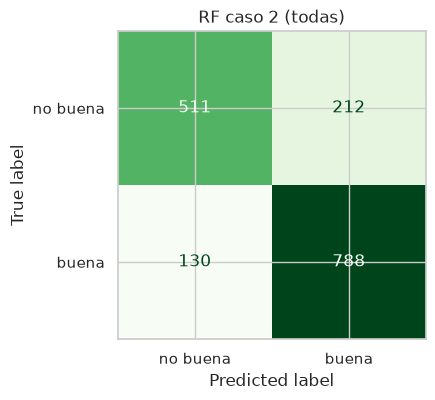

              precision    recall  f1-score   support

    no buena      0.797     0.707     0.749       723
       buena      0.788     0.858     0.822       918

    accuracy                          0.792      1641
   macro avg      0.793     0.783     0.785      1641
weighted avg      0.792     0.792     0.790      1641



In [34]:
# Parte B: todas las columnas, buscando min_samples_leaf y max_features
parametros_t, busqueda_t = buscar_rf(todas, "buena", "roc_auc", GRILLA_COMPLETA)
print(busqueda_t.round(4).to_string(index=False))
rf_t, pred_t, met_t = evaluar(crear_rf(**parametros_t), todas, "buena", "RF caso 2 (todas)", ETQ_BIN)

In [35]:
# Comparacion con la regresion logistica usando las mismas variables
log_2, _, met_2_log = evaluar(crear_logistica(), par, "buena", "Logistica 2 variables", ETQ_BIN, mostrar=False)
busqueda_c = GridSearchCV(crear_logistica(), {"logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
                          cv=cv, scoring="roc_auc").fit(train[todas], train["buena"], groups=train["titulo"])
log_t, _, met_t_log = evaluar(crear_logistica(busqueda_c.best_params_["logisticregression__C"]), todas, "buena",
                              "Logistica todas", ETQ_BIN, mostrar=False)

tabla_2 = pd.DataFrame([met_1_log, met_1, met_2_log, met_2, met_t_log, met_t]).set_index("modelo").round(4)
tabla_2

,n_variables,accuracy_train,accuracy,precision,recall,f1,auc
modelo,,,,,,,
Logistica caso 1,1,0.6987,0.7203,0.7611,0.7288,0.7446,0.7192
RF caso 1,1,0.6987,0.7203,0.7611,0.7288,0.7446,0.7192
Logistica 2 variables,2,0.7030,0.7227,0.7604,0.7364,0.7482,0.7940
RF caso 2 (2 variables),2,0.7105,0.7264,0.7487,0.7691,0.7587,0.7809
Logistica todas,54,0.7760,0.7831,0.7891,0.8355,0.8116,0.8544
RF caso 2 (todas),54,0.9389,0.7916,0.7880,0.8584,0.8217,0.8661


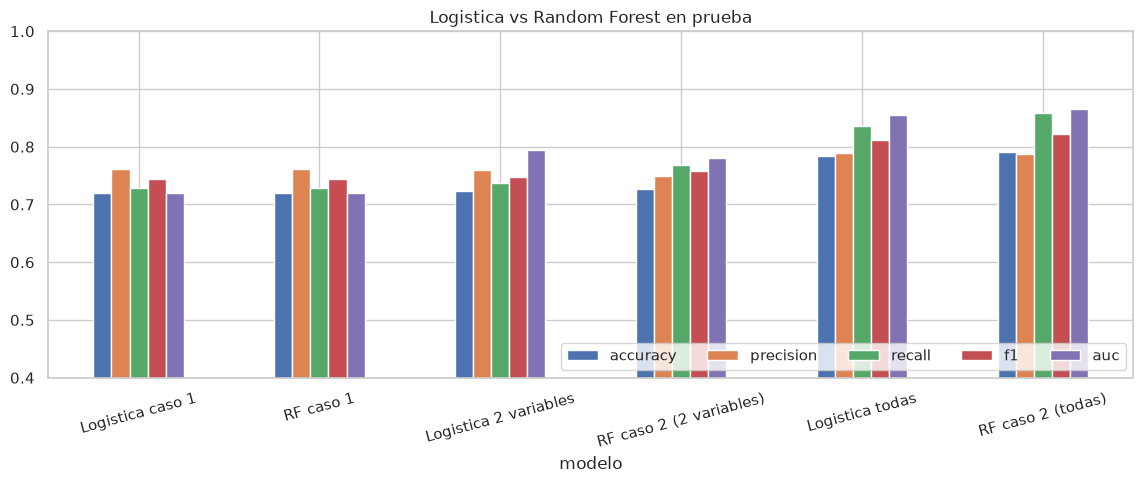

In [36]:
tabla_2[["accuracy", "precision", "recall", "f1", "auc"]].plot(kind="bar", figsize=(14, 4.5), rot=15, ylim=(0.4, 1))
plt.title("Logistica vs Random Forest en prueba")
plt.legend(loc="lower right", ncol=5)
plt.show()

### Curva ROC: logística contra Random Forest

La curva ROC compara los modelos con todos los umbrales de decisión y no solo con 0.5. El AUC vale 1 para un modelo perfecto y 0.5 para uno que adivina.

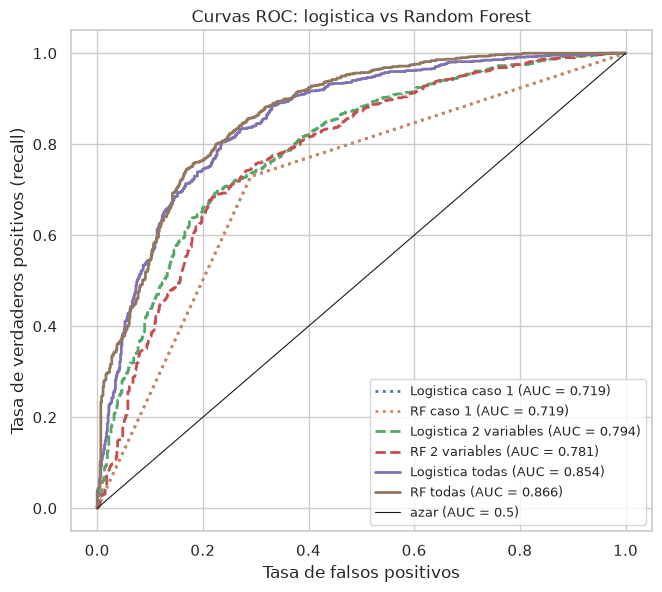

In [37]:
modelos_roc = {
    "Logistica caso 1": (log_1, [var_1]), "RF caso 1": (rf_1, [var_1]),
    "Logistica 2 variables": (log_2, par), "RF 2 variables": (rf_2, par),
    "Logistica todas": (log_t, todas), "RF todas": (rf_t, todas),
}
estilos = [":", ":", "--", "--", "-", "-"]
plt.figure(figsize=(7.5, 6.5))
for (nombre, (modelo, columnas)), estilo in zip(modelos_roc.items(), estilos):
    prob = modelo.predict_proba(test[columnas])[:, 1]
    fpr, tpr, _ = roc_curve(test["buena"], prob)
    plt.plot(fpr, tpr, lw=2, ls=estilo, label=f"{nombre} (AUC = {roc_auc_score(test['buena'], prob):.3f})")
plt.plot([0, 1], [0, 1], "k", lw=0.8, label="azar (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curvas ROC: logistica vs Random Forest")
plt.legend(loc="lower right", fontsize=9)
plt.show()

### Importancia de las variables

**Concepto: importancia de Gini.** Para cada columna se suma cuánto reduce la impureza de Gini en todas las divisiones de todos los árboles donde se usa. Sirve para ver en qué variables se apoya el modelo. Hay que leerla con cuidado, porque favorece a las variables numéricas con muchos valores distintos.

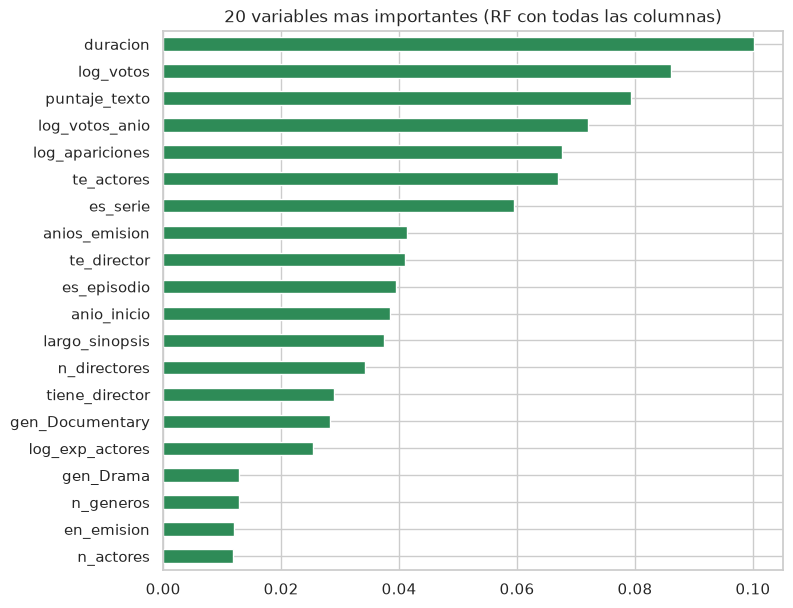

In [38]:
imp_t = pd.Series(rf_t.feature_importances_, index=todas).sort_values(ascending=False)
imp_t.head(20).sort_values().plot(kind="barh", figsize=(8, 7), color="seagreen")
plt.title("20 variables mas importantes (RF con todas las columnas)")
plt.show()

### Sobreajuste según el tamaño mínimo de las hojas

Para ver el sobreajuste de forma gráfica se entrenó el Random Forest con todas las columnas y distintos valores de `min_samples_leaf`, midiendo el accuracy en entrenamiento y en prueba. Esta gráfica es solo ilustrativa: el valor del modelo ya se había escogido antes con validación cruzada, sin mirar el conjunto de prueba.

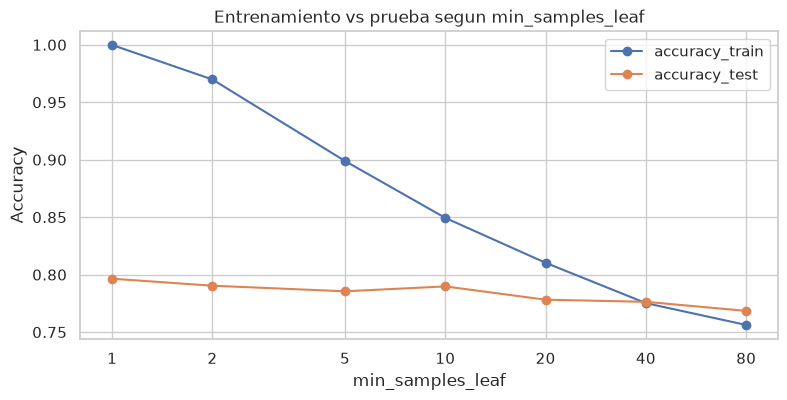

,accuracy_train,accuracy_test
min_samples_leaf,,
1,0.9998,0.7965
2,0.9698,0.7904
5,0.8989,0.7855
10,0.8494,0.7898
20,0.8103,0.7782
40,0.7752,0.7764
80,0.7562,0.7684


In [39]:
filas = []
for hoja in [1, 2, 5, 10, 20, 40, 80]:
    modelo = crear_rf(hoja, parametros_t.get("max_features", "sqrt")).fit(train[todas], train["buena"])
    filas.append({"min_samples_leaf": hoja,
                  "accuracy_train": accuracy_score(train["buena"], modelo.predict(train[todas])),
                  "accuracy_test": accuracy_score(test["buena"], modelo.predict(test[todas]))})
curva = pd.DataFrame(filas).set_index("min_samples_leaf")
eje = curva.plot(marker="o", figsize=(9, 4), logx=True)
eje.set_xticks(curva.index)
eje.set_xticklabels(curva.index)
eje.set_ylabel("Accuracy")
eje.set_title("Entrenamiento vs prueba segun min_samples_leaf")
plt.show()
curva.round(4)

### Conclusiones del caso 2

**Parte A (dos variables).** Aquí sí se ve el sobreajuste. Con árboles sin límite (`min_samples_leaf = 1`) el AUC en validación es 0.663, porque `puntaje_texto` es continuo y cada título tiene un valor casi único que los árboles memorizan. Al exigir 80 títulos por hoja el AUC de validación sube a 0.750. En prueba el Random Forest llega a un accuracy de **0.726** y un F1 de **0.759**, un poco mejor que la regresión logística (0.723 y 0.748), aunque con un AUC algo menor (0.781 contra 0.794). En la gráfica se ve la diferencia entre los dos modelos: la logística dibuja dos curvas suaves, mientras que el Random Forest aprende escalones.

**Parte B (todas las columnas).** Con las 54 columnas y los hiperparámetros escogidos por validación (`min_samples_leaf = 3` y `max_features = "sqrt"`), el Random Forest llega a un accuracy de **0.792**, precision de 0.788, recall de 0.858, F1 de **0.822** y AUC de **0.866**. Es el mejor resultado de todo el informe para el problema binario, y supera a la regresión logística con las mismas columnas (0.783, 0.812 y 0.854). En la matriz de confusión acierta 788 de 918 títulos buenos y 511 de 723 no buenos.

La curva ROC del Random Forest con todas las columnas queda por encima de las demás en casi todo el recorrido, así que su ventaja no depende del umbral que se escoja.

Las variables más importantes son la duración, los votos, el puntaje de la sinopsis, la popularidad por año, el número de episodios listados y el historial de los actores. Coinciden con lo que mostraron el análisis exploratorio y los coeficientes de la regresión logística, con la diferencia de que el Random Forest sí aprovecha los votos, cuya relación con el rating no es lineal.

**Sobreajuste.** El accuracy de entrenamiento es 0.939 contra 0.792 en prueba. La gráfica de `min_samples_leaf` muestra el comportamiento completo: con hojas de 1 título el modelo acierta el 99.98 % del entrenamiento, y a medida que se exigen hojas más grandes la brecha se cierra, hasta que con 80 títulos por hoja las dos métricas casi se igualan (75.6 % y 76.8 %), pero el modelo ya es demasiado simple y la prueba empeora. Las mejores métricas de prueba están en los valores pequeños, que es justo la zona que escogió la validación cruzada. En Random Forest es normal que el entrenamiento quede alto, porque cada árbol vio buena parte de esas filas; lo que importa es el desempeño en prueba.

## 8. Caso 3: Random Forest multiclase

**Enunciado.** Seleccionar todas las columnas característica y una variable objetivo de clasificación multiclase, obtener métricas de desempeño (matriz de confusión, accuracy, f1 score, precision, recall), remover las columnas característica que sean necesarias para mejorar las métricas y sacar conclusiones.

**Variable objetivo:** `categoria` (Baja, Media, Alta). **Variables características:** todas las columnas.

Random Forest maneja varias clases de forma natural: cada hoja guarda la proporción de cada clase y el bosque vota por la más probable. No hace falta entrenar un modelo por clase.

Mejores hiperparametros: {'max_features': 'sqrt', 'min_samples_leaf': 1}
max_features  min_samples_leaf  puntaje_validacion
        sqrt                 1              0.6099
         0.3                 1              0.6090
         0.3                 3              0.6085
        sqrt                 3              0.6036
         0.3                 5              0.6001
        sqrt                 5              0.5987
         0.3                10              0.5951
        sqrt                10              0.5901


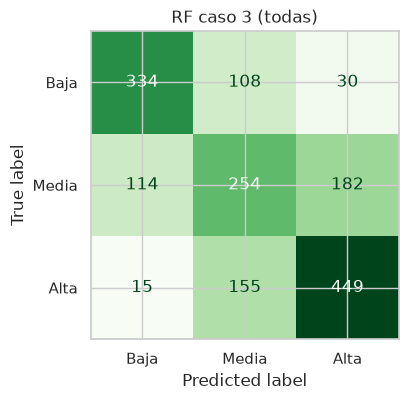

              precision    recall  f1-score   support

        Baja      0.721     0.708     0.714       472
       Media      0.491     0.462     0.476       550
        Alta      0.679     0.725     0.702       619

    accuracy                          0.632      1641
   macro avg      0.631     0.632     0.631      1641
weighted avg      0.628     0.632     0.630      1641



,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
RF caso 3 (todas),54,0.9992,0.6319,0.6307,0.6316,0.6307


In [40]:
parametros_3, busqueda_3 = buscar_rf(todas, "categoria", "f1_macro", GRILLA_COMPLETA)
print(busqueda_3.round(4).to_string(index=False))
rf_3, pred_3, met_3 = evaluar(crear_rf(**parametros_3), todas, "categoria", "RF caso 3 (todas)", ETQ_MULTI)
pd.DataFrame([met_3]).set_index("modelo").round(4)

### Eliminación de columnas

Para decidir qué columnas quitar se compararon dos medidas de importancia:

1. **Importancia de Gini:** la calcula el propio Random Forest durante el entrenamiento. Es rápida, pero favorece a las columnas numéricas con muchos valores distintos aunque no ayuden a predecir.
2. **Importancia por permutación:** se toma un conjunto de validación, se desordenan al azar los valores de una sola columna y se mide cuánto baja el F1. Si el F1 casi no cambia, o incluso sube, la columna no le aporta nada al modelo. Se calculó con validación cruzada dentro del entrenamiento, así que mide la utilidad real de cada columna en datos que el modelo no vio.

Con cada medida se probaron varios umbrales, quitando las columnas con importancia menor al umbral. Cada conjunto se evaluó con validación cruzada en el entrenamiento y solo el ganador se evaluó una vez en prueba. Si las columnas se escogieran mirando el conjunto de prueba, la métrica final quedaría inflada.

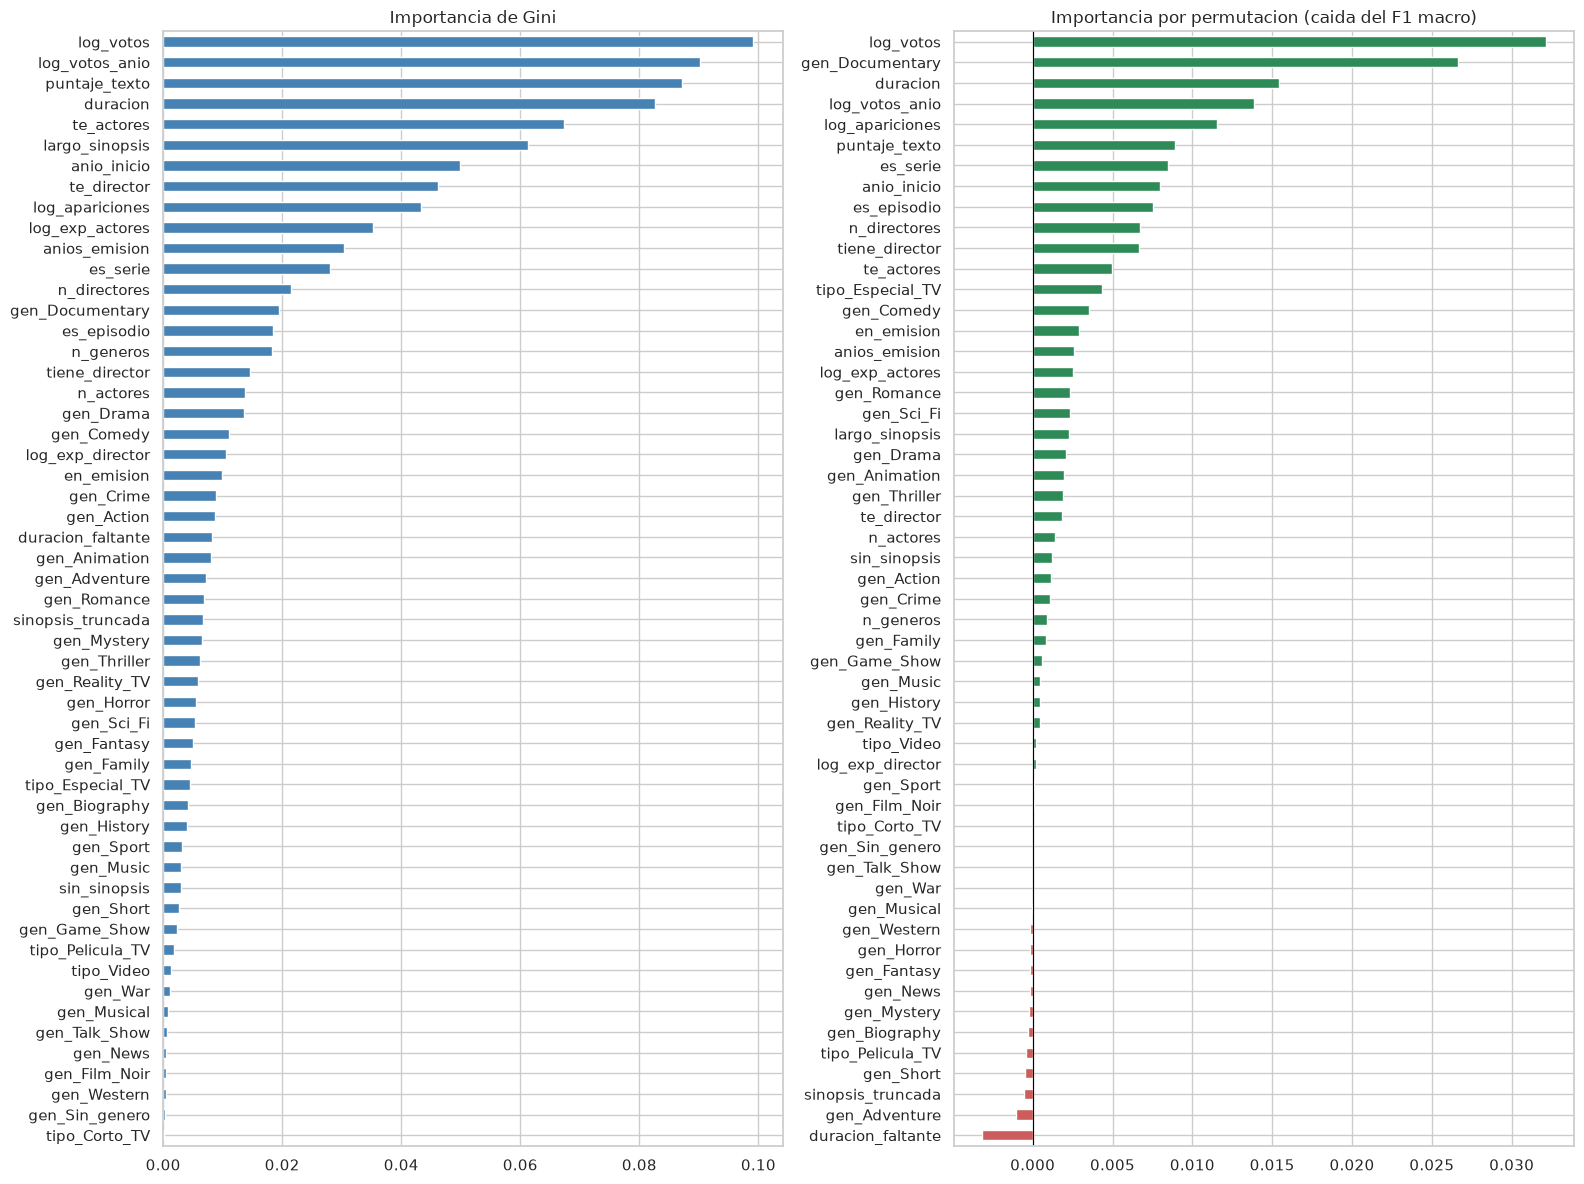

Columnas con importancia por permutacion menor o igual a 0: ['duracion_faltante', 'gen_Adventure', 'gen_Biography', 'gen_Fantasy', 'gen_Horror', 'gen_Musical', 'gen_Mystery', 'gen_News', 'gen_Short', 'gen_Sin_genero', 'gen_Talk_Show', 'gen_War', 'gen_Western', 'sinopsis_truncada', 'tipo_Corto_TV', 'tipo_Pelicula_TV']


In [41]:
# Importancia de Gini del modelo multiclase con todas las columnas
imp_gini = pd.Series(rf_3.feature_importances_, index=todas)

# Importancia por permutacion: en cada particion se entrena con cuatro partes y se permuta sobre la quinta
from sklearn.inspection import permutation_importance
importancias = []
for idx_ajuste, idx_valid in cv.split(train, groups=train["titulo"]):
    modelo = crear_rf(**parametros_3).fit(train.iloc[idx_ajuste][todas], train.iloc[idx_ajuste]["categoria"])
    resultado = permutation_importance(modelo, train.iloc[idx_valid][todas], train.iloc[idx_valid]["categoria"],
                                       scoring="f1_macro", n_repeats=3, random_state=SEMILLA, n_jobs=-1)
    importancias.append(resultado.importances_mean)
imp_perm = pd.Series(np.mean(importancias, axis=0), index=todas)

fig, ejes = plt.subplots(1, 2, figsize=(16, 12))
imp_gini.sort_values().plot(kind="barh", ax=ejes[0], color="steelblue")
ejes[0].set_title("Importancia de Gini")
imp_perm.sort_values().plot(kind="barh", ax=ejes[1], color=np.where(imp_perm.sort_values() > 0, "seagreen", "indianred"))
ejes[1].axvline(0, color="black", lw=0.8)
ejes[1].set_title("Importancia por permutacion (caida del F1 macro)")
plt.tight_layout()
plt.show()
print("Columnas con importancia por permutacion menor o igual a 0:", sorted(imp_perm[imp_perm <= 0].index))

In [42]:
# Conjuntos candidatos de columnas
candidatos = {"Todas": todas}
for u in [0.005, 0.01]:
    candidatos[f"Gini > {u}"] = [c for c in todas if imp_gini[c] > u]
for u in [0, 0.0005, 0.001]:
    candidatos[f"Permutacion > {u}"] = [c for c in todas if imp_perm[c] > u]

# F1 macro en validacion cruzada agrupada de cada conjunto, solo con el entrenamiento
filas = []
for nombre, columnas in candidatos.items():
    f1_cv = cross_val_score(crear_rf(**parametros_3), train[columnas], train["categoria"],
                            groups=train["titulo"], cv=cv, scoring="f1_macro").mean()
    filas.append({"conjunto": nombre, "n_columnas": len(columnas), "f1_macro_validacion": f1_cv})
tabla_cand = pd.DataFrame(filas).set_index("conjunto")
tabla_cand.round(4)

,n_columnas,f1_macro_validacion
conjunto,,
Todas,54,0.6099
Gini > 0.005,34,0.6073
Gini > 0.01,21,0.6010
Permutacion > 0,38,0.6127
Permutacion > 0.0005,31,0.6058
Permutacion > 0.001,28,0.6090


Conjunto elegido: Permutacion > 0 (38 columnas)
Columnas eliminadas: ['duracion_faltante', 'gen_Adventure', 'gen_Biography', 'gen_Fantasy', 'gen_Horror', 'gen_Musical', 'gen_Mystery', 'gen_News', 'gen_Short', 'gen_Sin_genero', 'gen_Talk_Show', 'gen_War', 'gen_Western', 'sinopsis_truncada', 'tipo_Corto_TV', 'tipo_Pelicula_TV']


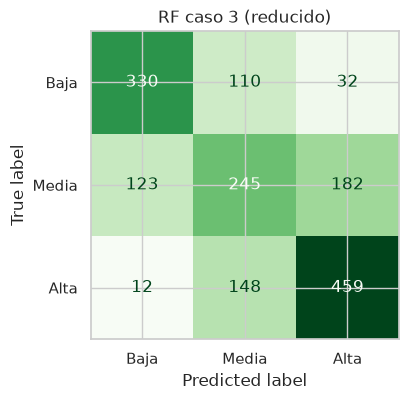

              precision    recall  f1-score   support

        Baja      0.710     0.699     0.704       472
       Media      0.487     0.445     0.465       550
        Alta      0.682     0.742     0.711       619

    accuracy                          0.630      1641
   macro avg      0.626     0.629     0.627      1641
weighted avg      0.625     0.630     0.627      1641



,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
RF caso 3 (todas),54,0.9992,0.6319,0.6307,0.6316,0.6307
RF caso 3 (reducido),38,0.9992,0.6301,0.6263,0.6287,0.6267


In [43]:
# El conjunto con mejor F1 en validacion se evalua una sola vez en prueba
nombre_mejor = tabla_cand["f1_macro_validacion"].idxmax()
cols_final = candidatos[nombre_mejor]
print(f"Conjunto elegido: {nombre_mejor} ({len(cols_final)} columnas)")
print("Columnas eliminadas:", sorted(set(todas) - set(cols_final)))
rf_3b, pred_3b, met_3b = evaluar(crear_rf(**parametros_3), cols_final, "categoria", "RF caso 3 (reducido)", ETQ_MULTI)
pd.DataFrame([met_3, met_3b]).set_index("modelo").round(4)

### Matriz de confusión normalizada

En la matriz normalizada cada fila suma 1, así que cada casilla dice qué proporción de los títulos de una clase real terminó en cada clase predicha. Así las clases se comparan aunque no tengan el mismo tamaño.

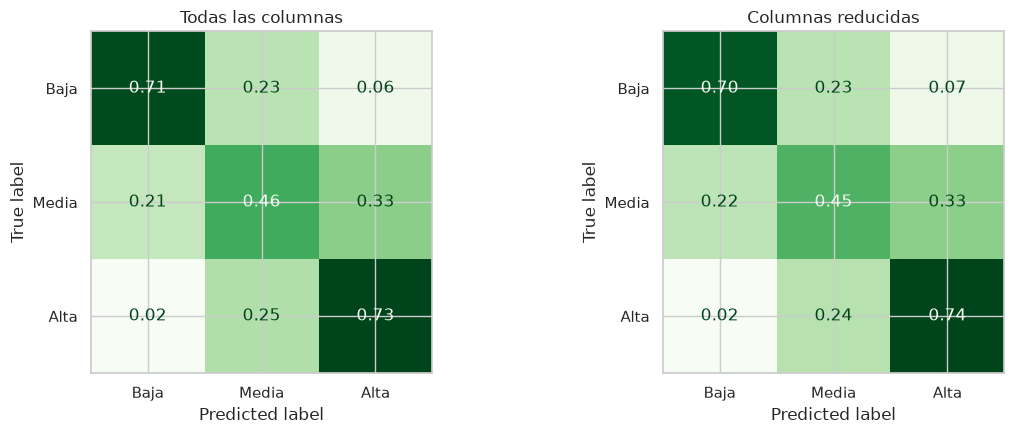

In [44]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
for eje, pred, titulo in [(ejes[0], pred_3, "Todas las columnas"), (ejes[1], pred_3b, "Columnas reducidas")]:
    ConfusionMatrixDisplay.from_predictions(test["categoria"], pred, labels=ETQ_MULTI, normalize="true",
                                            values_format=".2f", cmap="Greens", colorbar=False, ax=eje)
    eje.set_title(titulo)
plt.tight_layout()
plt.show()

### Conclusiones del caso 3

Con todas las columnas el modelo multiclase llega a un accuracy de **0.632** y un F1 macro de **0.631**, muy por encima del 0.366 de predecir siempre la clase más frecuente. Es más bajo que en el problema binario, lo cual es normal: con tres clases hay más formas de equivocarse y los límites entre clases están separados por solo un punto de rating.

El reporte por clase muestra dónde está la dificultad. Baja (F1 de 0.714) y Alta (F1 de 0.702) se predicen razonablemente bien, pero **Media** tiene un F1 de 0.476. Está en el medio: un título de 6.6 se parece mucho a uno de 6.4 (baja) y uno de 7.4 se parece mucho a uno de 7.6 (alta). En la matriz normalizada, el 71 % de los títulos de rating bajo y el 73 % de los de rating alto quedan bien clasificados, mientras que de los títulos medios el 46 % se clasifica bien, el 33 % se va a Alta y el 21 % a Baja. Los errores entre extremos son muy pocos: solo el 6 % de los títulos bajos se predicen como altos y el 2 % de los altos como bajos.

**Eliminación de columnas.** Las dos medidas de importancia no coinciden. Quitar columnas por importancia de Gini empeoró la validación (0.607 y 0.601 contra 0.610 con todas), porque Gini sobrevalora las columnas numéricas y castiga a las binarias aunque sean útiles. La importancia por permutación, en cambio, encontró 16 columnas que no aportan nada o que incluso empeoran el F1 cuando se usan: 12 columnas de género (incluida la de títulos sin género), dos tipos con muy pocos títulos, `duracion_faltante` y `sinopsis_truncada`. Entre los géneros eliminados está terror, que en el análisis exploratorio sí cambiaba el rating; su información ya queda recogida en `puntaje_texto`, que se calcula con la sinopsis y el género, y por eso la columna aparte sobra. Al quitarlas, el F1 de validación sube de 0.610 a **0.613**, y fue el conjunto elegido.

En prueba el modelo reducido obtiene un F1 macro de 0.627 y un accuracy de 0.630, prácticamente igual al modelo completo (0.631 y 0.632). Una diferencia de 0.004 en 1641 títulos equivale a unos pocos títulos y está dentro del ruido de la división. La conclusión es que con 16 columnas menos (38 en vez de 54) se obtiene el mismo desempeño, así que esas columnas no aportaban información. Para mejorar de verdad la clase media harían falta variables que el dataset no tiene.

## 9. Conclusiones generales

1. Random Forest obtuvo los mejores resultados del informe. En el problema binario con todas las columnas llegó a un accuracy de 0.792, un F1 de 0.822 y un AUC de 0.866, por encima de la regresión logística (0.783, 0.812 y 0.854).
2. Con una sola variable binaria, Random Forest y regresión logística son equivalentes, porque las predicciones posibles son las mismas. La ventaja de los árboles aparece con variables continuas y relaciones no lineales, como la de los votos con el rating.
3. Random Forest necesita control del sobreajuste. Con pocas variables continuas y árboles sin límite memoriza el entrenamiento, y escoger `min_samples_leaf` y `max_features` con validación cruzada fue lo que permitió generalizar.
4. El problema multiclase es bastante más difícil, sobre todo para la clase media. La importancia por permutación permitió quitar 16 columnas sin perder desempeño, mientras que la importancia de Gini habría quitado columnas útiles.
5. Buena parte del resultado viene de la limpieza y la construcción de variables: las más importantes (estructura de serie, puntaje de la sinopsis, historial del reparto, popularidad por año) no existían en el archivo original.
6. Separar entrenamiento y prueba por título y escoger todo con validación cruzada hace que las métricas sean una estimación honesta del desempeño con títulos nuevos. El techo del modelo viene de que el dataset no incluye lo que más determina la calidad de un título.